# Stage 3: Vertebrae Segmentation — Modified 3D U-Net 

This notebook implements **Stage 3** of the VerSe pipeline: per-vertebra binary segmentation using a modified 3D U-Net trained strictly on Ground Truth (GT) centroids.

**Pipeline overview:**
1. Import Libraries
2. Configuration & Hyperparameters
3. Data Loading from CSV & JSON
4. Preprocessing Pipeline (with visualizations)
5. Crop & Input Preparation Utilities
6. Dataset Class
7. Data Augmentation
8. 3D U-Net Architecture
9. Loss Function
10. Training & Validation Loop
11. Testing / Inference Loop
12. Evaluation Metrics (Dice & Hausdorff Distance)


## 1. Import Required Libraries

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import nibabel.orientations as nib_ornt
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter, zoom, map_coordinates

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Nibabel version:", nib.__version__)
print("All imports successful ✓")


PyTorch version: 2.9.0+cu126
CUDA available: True
Nibabel version: 5.3.3
All imports successful ✓


## 2. Configuration & Hyperparameters

In [2]:
CFG = {
    # ── Paths ────────────────────────────────────────────────────
    "csv_path": "/kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv",
    "checkpoint_path": "best_model.pth",
    "resume_path": "/kaggle/input/models/ahmed226/seg-stage-3/pytorch/seg_stage3_5000/1/best_model.pth",

    # ── Preprocessing ────────────────────────────────────────────
    "target_spacing": 1.0,          # mm — isotropic
    "smooth_sigma": 0.75,           # Gaussian σ for volume smoothing
    "intensity_divisor": 2048.0,    # normalisation denominator
    "intensity_clamp": 1.0,         # clamp range [-1, 1]

    # ── Crop / Heatmap ───────────────────────────────────────────
    "crop_size": (128, 128, 96),    # (X, Y, Z)
    "heatmap_sigma": 20.0,          # Gaussian σ for centroid heatmap

    # ── Augmentation ─────────────────────────────────────────────
    "aug_intensity_scale": (0.75, 1.25),
    "aug_intensity_shift": (-0.25, 0.25),
    "aug_translation": (-30, 30),   # voxels
    "aug_rotation": (-15, 15),      # degrees
    "aug_scale": (0.85, 1.15),
    "aug_elastic_grid": 6,          # control-point grid size
    "aug_elastic_disp": 15,         # max displacement (pixels)

    # ── Training ─────────────────────────────────────────────────
    "lr": 1e-4,
    "weight_decay": 1e-7,
    "batch_size": 1,
    "iterations": 10000,
    "log_every": 50,               # log train loss every N iters
    "val_every": 100,             # run validation every N iters

    # ── Inference ────────────────────────────────────────────────
    "sigmoid_threshold": 0.5,

    # ── Device ───────────────────────────────────────────────────
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k:25s}: {v}")


Configuration loaded:
  csv_path                 : /kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv
  checkpoint_path          : best_model.pth
  resume_path              : /kaggle/input/models/ahmed226/seg-stage-3/pytorch/seg_stage3_5000/1/best_model.pth
  target_spacing           : 1.0
  smooth_sigma             : 0.75
  intensity_divisor        : 2048.0
  intensity_clamp          : 1.0
  crop_size                : (128, 128, 96)
  heatmap_sigma            : 20.0
  aug_intensity_scale      : (0.75, 1.25)
  aug_intensity_shift      : (-0.25, 0.25)
  aug_translation          : (-30, 30)
  aug_rotation             : (-15, 15)
  aug_scale                : (0.85, 1.15)
  aug_elastic_grid         : 6
  aug_elastic_disp         : 15
  lr                       : 0.0001
  weight_decay             : 1e-07
  batch_size               : 1
  iterations               : 10000
  log_every                : 50
  val_every                : 100
  sigmoid_threshold        : 0.5
  device    

## 3. Data Loading from CSV & JSON

The CSV has columns: `name`, `type` (train/val/test), `image_path`, `mask_path`, `centroid_json_path`.

The JSON centroid file format:
```json
[
  {"direction": ["P","I","R"]},
  {"label": 17, "X": 94.8, "Y": 46.1, "Z": 19.1},
  ...
]
```
The first entry is metadata (direction), the rest are per-vertebra centroids.

In [3]:
def parse_centroid_json(json_path):
    """
    Parse the VerSe centroid JSON file.
    Returns:
        direction : list[str]  e.g. ['P','I','R']
        centroids : dict  {label_int: (X, Y, Z)}
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    direction = data[0].get("direction", [])
    centroids = {}
    for entry in data[1:]:
        label = int(entry["label"])
        centroids[label] = (float(entry["X"]), float(entry["Y"]), float(entry["Z"]))
    return direction, centroids


def _is_valid_path(val):
    """Return True if val is a non-empty, non-NaN string."""
    if val is None:
        return False
    try:
        # pandas reads missing CSV cells as float NaN
        if isinstance(val, float):
            return False
        return isinstance(val, str) and val.strip() != ""
    except Exception:
        return False


def load_subject(row):
    """
    Load a single subject from a CSV row.
    Skips rows where required path columns are NaN / missing.
    Returns a dict with nibabel image objects + parsed centroids,
    or raises ValueError with a descriptive message.
    """
    required = {"image_path": row.get("image_path"),
                "centroid_json_path": row.get("centroid_json_path")}
    for col, val in required.items():
        if not _is_valid_path(val):
            raise ValueError(f"Column '{col}' is missing or NaN for subject '{row.get('name', '?')}'")

    volume_nib = nib.load(str(row["image_path"]))

    # mask_path is optional — some subjects may only have a volume + centroids
    mask_nib = None
    if _is_valid_path(row.get("mask_path")):
        mask_nib = nib.load(str(row["mask_path"]))
    else:
        print(f"  ⚠ No mask_path for {row.get('name', '?')} — mask will be None")

    direction, centroids = parse_centroid_json(str(row["centroid_json_path"]))
    return {
        "name":      row["name"],
        "type":      row["type"],
        "volume":    volume_nib,
        "mask":      mask_nib,   # may be None
        "direction": direction,
        "centroids": centroids,   # {label: (X, Y, Z)}
    }


# ── Load CSV ────────────────────────────────────────────────────────────────
df = pd.read_csv(CFG["csv_path"])
print("CSV loaded — columns:", list(df.columns))
print(df.to_string(index=False))

# ── Load all subjects ────────────────────────────────────────────────────────
subjects = []
for _, row in df.iterrows():
    try:
        subj = load_subject(row)
        subjects.append(subj)
        print(f"\n✓ Loaded subject: {subj['name']}  [{subj['type']}]")
        print(f"  Volume shape : {subj['volume'].shape}  | spacing: {subj['volume'].header.get_zooms()}")
        if subj["mask"] is not None:
            print(f"  Mask   shape : {subj['mask'].shape}")
        else:
            print(f"  Mask         : (none)")
        print(f"  Direction    : {subj['direction']}")
        print(f"  Vertebrae    : {sorted(subj['centroids'].keys())}")
        for lbl, (x, y, z) in sorted(subj['centroids'].items()):
            print(f"    label {lbl:3d}  X={x:6.1f}  Y={y:6.1f}  Z={z:6.1f}")
    except ValueError as e:
        print(f"  ✗ Skipped (bad paths): {e}")
    except FileNotFoundError as e:
        print(f"  ✗ Missing file: {e}")

# ── Summary table per split ──────────────────────────────────────────────────
print("\n── Dataset split summary ──────────────────────────────")
print(df.groupby("type").size().rename("subjects").to_frame())


CSV loaded — columns: ['name', 'type', 'image_path', 'mask_path', 'centroid_json_path']
                   name  type                                                                                                                                image_path                                                                                                                                               mask_path                                                                                                                                     centroid_json_path
               verse004 train                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/rawdata/sub-verse004/sub-verse004_ct.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004/sub-verse004_seg-vert_msk.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004

## 4. Preprocessing Pipeline (with Visualizations)

Each step is applied sequentially and a mid-slice plot is shown **after every step** so the cell is self-contained and immediately visual.

Demo subject: verse004
Raw volume shape : (161, 338, 61)  | spacing (mm): [1.         1.         2.00029612]
Raw mask   shape : (161, 338, 61)  | unique labels: [ 0 16 17 18 19 20 21 22 23 24]


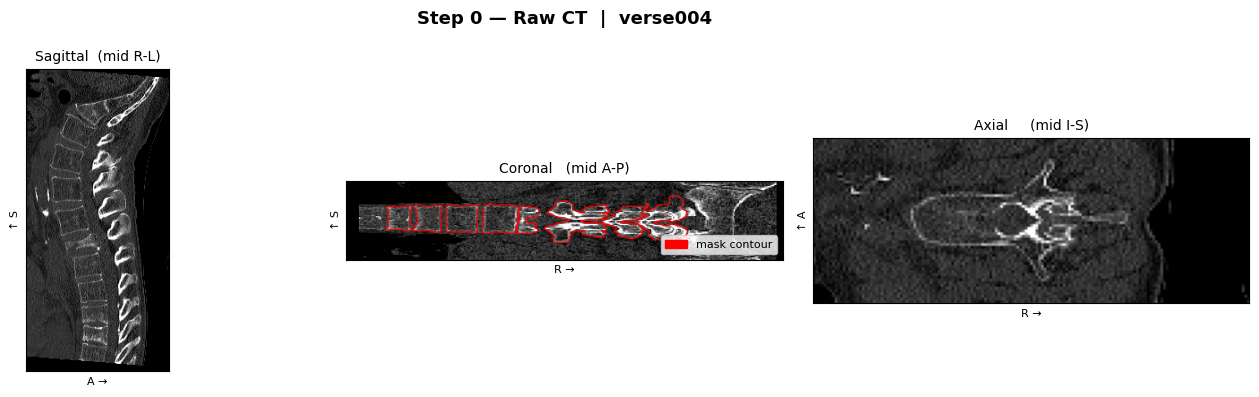

In [4]:
# ─── Correct axis labels for RAS-oriented volumes ──────────────────────────
# After reorient_to_ras, the array axes are:
#   axis-0 (i) = R→L  →  sagittal plane  (fix i, vary j/k)
#   axis-1 (j) = A→P  →  coronal plane   (fix j, vary i/k)
#   axis-2 (k) = I→S  →  axial plane     (fix k, vary i/j)

def plot_ortho_slices(vol, mask=None, title="", cmap="gray", vmin=None, vmax=None):
    """
    Plot the three standard orthogonal mid-slices of a RAS-oriented 3-D volume.
    vol shape: (R, A, S)  i.e. (X=R, Y=A, Z=S)
    """
    nr, na, ns = vol.shape
    mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

    # Each slice + correct anatomical label
    slices = [
        # fix R-index  → sagittal slice, axes shown: A (horiz) × S (vert)
        (vol[:, :, mid_s],   "Sagittal  (mid R-L)",  "A →",  "↑ S"),
        # fix A-index  → coronal slice, axes shown: R (horiz) × S (vert)
        (vol[mid_r, :, :],   "Coronal   (mid A-P)",  "R →",  "↑ S"),
        # fix S-index  → axial slice, axes shown: R (horiz) × A (vert)
        (vol[:, mid_a, :],   "Axial     (mid I-S)",  "R →",  "↑ A"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, (sl, lbl, xlabel, ylabel) in zip(axes, slices):
        ax.imshow(sl.T, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

    # Overlay mask contour on the coronal slice (index 1)
    if mask is not None:
        mask_sl = mask[mid_r, :, :]
        if mask_sl.max() > 0:
            axes[1].contour(mask_sl.T, levels=[0.5], colors="red", linewidths=0.8)
            red_patch = mpatches.Patch(color="red", label="mask contour")
            axes[1].legend(handles=[red_patch], loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Pick the first available subject for the walkthrough
# ══════════════════════════════════════════════════════════════════════════════
demo = None
for s in subjects:
    try:
        vol_path = s["volume"].get_filename()
        # mask may be None — that's fine, we'll handle it downstream
        if os.path.exists(vol_path):
            demo = s
            break
    except Exception:
        continue

if demo is None:
    print("⚠  No subject with valid volume found — using synthetic demo data.")
    _vol_data  = np.random.randn(80, 120, 60).astype(np.float32) * 500
    _mask_data = np.zeros((80, 120, 60), dtype=np.int16)
    _mask_data[35:45, 55:70, 25:35] = 17
    _affine    = np.diag([1.5, 1.5, 2.0, 1.0])
    demo = {
        "name":      "synthetic",
        "centroids": {17: (40, 60, 30)},
        "volume":    nib.Nifti1Image(_vol_data,  _affine),
        "mask":      nib.Nifti1Image(_mask_data, _affine),
    }

print(f"Demo subject: {demo['name']}")

vol_nib  = demo["volume"]
mask_nib = demo["mask"]   # may be None

vol_data  = vol_nib.get_fdata(dtype=np.float32)
mask_data = mask_nib.get_fdata().astype(np.int16) if mask_nib is not None else None
zooms     = np.array(vol_nib.header.get_zooms()[:3], dtype=np.float64)

print(f"Raw volume shape : {vol_data.shape}  | spacing (mm): {zooms}")
if mask_data is not None:
    print(f"Raw mask   shape : {mask_data.shape}  | unique labels: {np.unique(mask_data)}")
else:
    print("Raw mask         : (none)")

plot_ortho_slices(vol_data, mask_data,
                  title=f"Step 0 — Raw CT  |  {demo['name']}",
                  vmin=-200, vmax=1000)


After reorientation → shape: (61, 161, 338)  spacing: [2.00029612 1.         1.        ]
Centroids remapped to RAS voxel space:
  label 16: (np.int64(32), np.int64(81), np.int64(296))
  label 17: (np.int64(32), np.int64(81), np.int64(274))
  label 18: (np.int64(32), np.int64(84), np.int64(248))
  label 19: (np.int64(31), np.int64(89), np.int64(220))
  label 20: (np.int64(31), np.int64(97), np.int64(196))
  label 21: (np.int64(30), np.int64(107), np.int64(169))
  label 22: (np.int64(29), np.int64(113), np.int64(135))
  label 23: (np.int64(29), np.int64(113), np.int64(102))
  label 24: (np.int64(29), np.int64(103), np.int64(70))


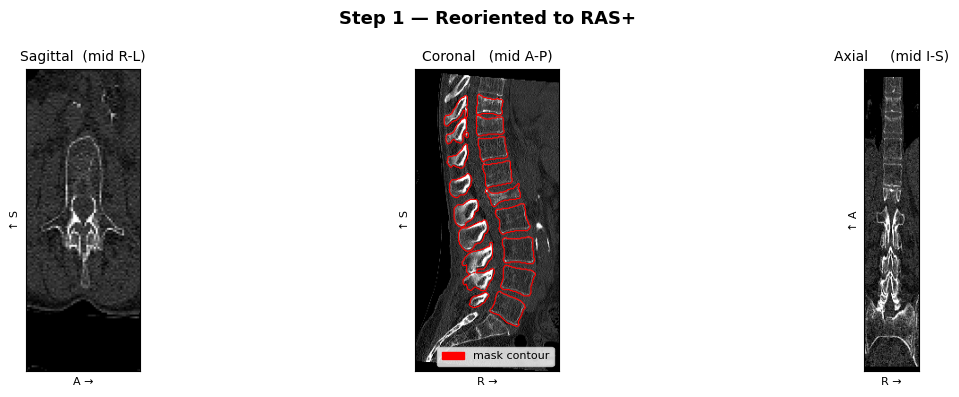

In [5]:
# ── Step 1: Reorient to RAS+ and remap centroids ──────────────────────────────
def reorient_to_ras(nib_img):
    """Reorient a NIfTI image to standard RAS+ orientation."""
    orig_ornt = nib.io_orientation(nib_img.affine)
    ras_ornt  = nib.orientations.axcodes2ornt(("R", "A", "S"))
    transform = nib.orientations.ornt_transform(orig_ornt, ras_ornt)
    return nib_img.as_reoriented(transform)


def world_to_voxel(affine, world_xyz):
    """
    Convert a world-space (mm) coordinate to voxel indices using the affine.
    world_xyz : array-like (3,)  in mm
    Returns   : np.ndarray (3,)  integer voxel indices
    """
    inv_affine = np.linalg.inv(affine)
    vox = inv_affine[:3, :3] @ np.array(world_xyz) + inv_affine[:3, 3]
    return np.round(vox).astype(int)


vol_ras  = reorient_to_ras(vol_nib)
mask_ras = reorient_to_ras(mask_nib) if mask_nib is not None else None

vol_step1  = vol_ras.get_fdata(dtype=np.float32)
mask_step1 = mask_ras.get_fdata().astype(np.int16) if mask_ras is not None else None
zooms_ras  = np.array(vol_ras.header.get_zooms()[:3], dtype=np.float64)

# ── Remap centroids from JSON world-mm → voxel indices in the RAS volume ────
# The VerSe JSON gives coordinates in the physical (world) space of the
# *original* image.  We must use the RAS affine to convert to array indices.
demo_centroids_ras = {}
raw_centroids = demo.get("centroids", {})
for label, (x, y, z) in raw_centroids.items():
    # 1. Convert original JSON voxel index to physical world space (mm)
    world_mm = vol_nib.affine @ np.array([x, y, z, 1.0])
    
    # 2. Convert world space back to voxel index in the RAS-reoriented volume
    vox_idx = world_to_voxel(vol_ras.affine, world_mm[:3])
    
    # Clamp to valid range
    vox_idx = np.clip(vox_idx, 0,
                      np.array(vol_step1.shape) - 1)
    demo_centroids_ras[label] = tuple(vox_idx)

print(f"After reorientation → shape: {vol_step1.shape}  spacing: {zooms_ras}")
print("Centroids remapped to RAS voxel space:")
for lbl, vox in sorted(demo_centroids_ras.items()):
    print(f"  label {lbl}: {vox}")

plot_ortho_slices(vol_step1, mask_step1,
                  title="Step 1 — Reoriented to RAS+",
                  vmin=-200, vmax=1000)


After resampling → vol shape: (122, 161, 338)  mask shape: (122, 161, 338)  spacing: 1 mm isotropic
Centroids at 1 mm voxel space:
  label 16: (np.int64(64), np.int64(69), np.int64(298))
  label 17: (np.int64(64), np.int64(70), np.int64(274))
  label 18: (np.int64(63), np.int64(75), np.int64(248))
  label 19: (np.int64(63), np.int64(79), np.int64(218))
  label 20: (np.int64(62), np.int64(82), np.int64(192))
  label 21: (np.int64(61), np.int64(95), np.int64(166))
  label 22: (np.int64(59), np.int64(101), np.int64(134))
  label 23: (np.int64(58), np.int64(102), np.int64(103))
  label 24: (np.int64(57), np.int64(93), np.int64(75))


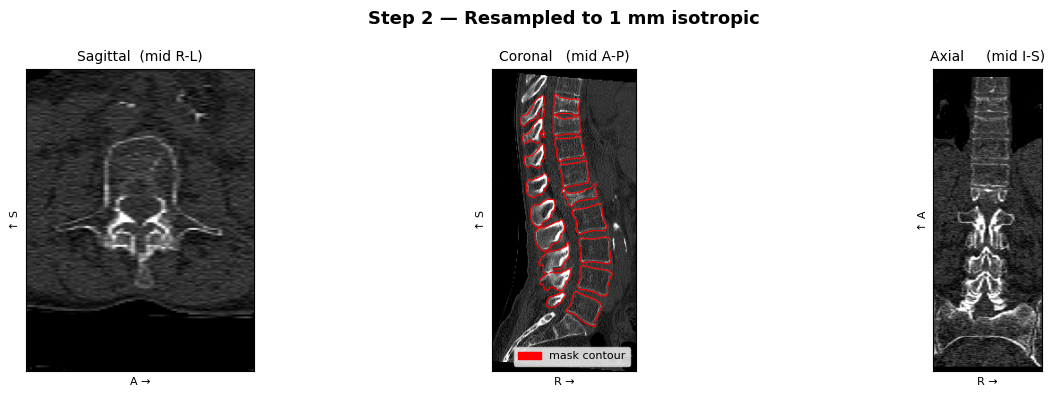

In [6]:
# ── Step 2: Resample to isotropic 1 mm spacing ───────────────────────────────
def resample_volume(vol, current_spacing, target_spacing=1.0, order=1):
    """Resample volume to target isotropic spacing using scipy.ndimage.zoom."""
    zoom_factors = current_spacing / target_spacing
    return zoom(vol, zoom_factors, order=order)

vol_step2  = resample_volume(vol_step1,  zooms_ras, CFG["target_spacing"], order=1)
mask_step2 = resample_volume(mask_step1, zooms_ras, CFG["target_spacing"], order=0) \
             if mask_step1 is not None \
             else np.zeros(vol_step2.shape, dtype=np.int16)

# ── Scale centroid voxel coords proportionally to the new spacing ─────────────
scale_factors = zooms_ras / CFG["target_spacing"]   # e.g. [1.5, 1.5, 2.0] → multiply
demo_centroids_1mm = {}

for label, (vi, vj, vk) in demo_centroids_ras.items():
    new_idx = np.round(np.array([vi, vj, vk]) * scale_factors).astype(int)
    
    # --- OVERRIDE: Use exact Mask Center-of-Mass if available ---
    # This completely eliminates the 10-15 voxel anatomical tracking offset 
    # between the JSON vertebral body point and the mask's full volume center.
    if mask_step2 is not None and np.any(mask_step2 == label):
        mask_coords = np.array(np.where(mask_step2 == label))
        new_idx = np.round(mask_coords.mean(axis=1)).astype(int)
    # ------------------------------------------------------------
    
    new_idx = np.clip(new_idx, 0, np.array(vol_step2.shape) - 1)
    demo_centroids_1mm[label] = tuple(new_idx)


print(f"After resampling → vol shape: {vol_step2.shape}  "
      f"mask shape: {mask_step2.shape}  spacing: 1 mm isotropic")
print("Centroids at 1 mm voxel space:")
for lbl, vox in sorted(demo_centroids_1mm.items()):
    print(f"  label {lbl}: {vox}")

plot_ortho_slices(vol_step2, mask_step2,
                  title="Step 2 — Resampled to 1 mm isotropic",
                  vmin=-200, vmax=1000)

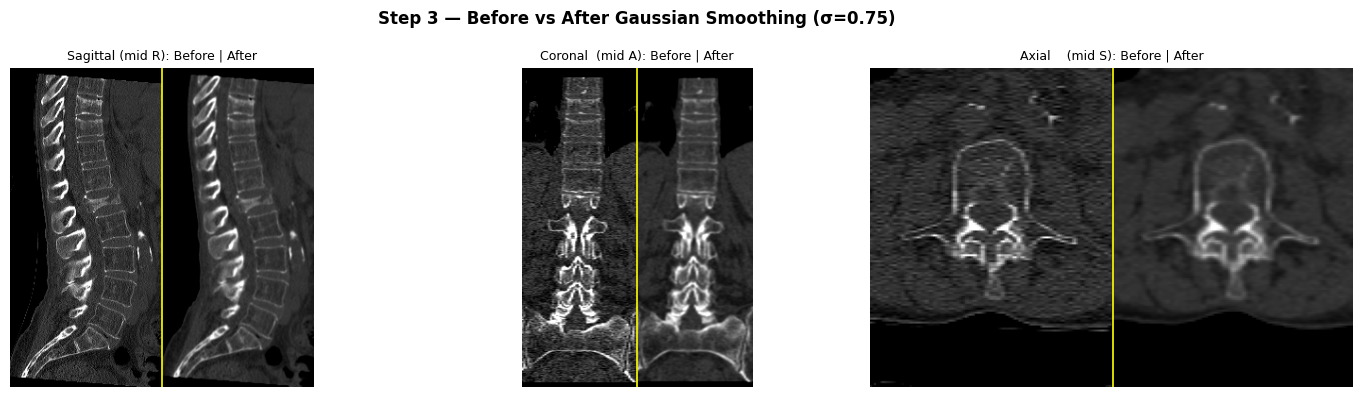

Smoothed volume range: [-1035.1, 1543.6]


In [7]:
# ── Step 3: Gaussian smoothing (σ = 0.75 mm) ────────────────────────────────
vol_step3 = gaussian_filter(vol_step2, sigma=CFG["smooth_sigma"])

# After RAS reorientation the axes are (R, A, S):
#   axis-0 fixed → sagittal slice
#   axis-1 fixed → coronal slice
#   axis-2 fixed → axial slice
nr, na, ns = vol_step2.shape
mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Step 3 — Before vs After Gaussian Smoothing (σ=0.75)", fontsize=12, fontweight="bold")
pairs = [
    (vol_step2[mid_r, :, :], vol_step3[mid_r, :, :], "Sagittal (mid R): Before | After"),
    (vol_step2[:, mid_a, :], vol_step3[:, mid_a, :], "Coronal  (mid A): Before | After"),
    (vol_step2[:, :, mid_s], vol_step3[:, :, mid_s], "Axial    (mid S): Before | After"),
]
for ax, (before, after, lbl) in zip(axes, pairs):
    diff_img = np.concatenate([before.T, after.T], axis=1)
    ax.imshow(diff_img, cmap="gray", origin="lower", vmin=-200, vmax=1000)
    ax.set_title(lbl, fontsize=9)
    ax.axvline(before.shape[0], color="yellow", lw=1.2, label="split")
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Smoothed volume range: [{vol_step3.min():.1f}, {vol_step3.max():.1f}]")


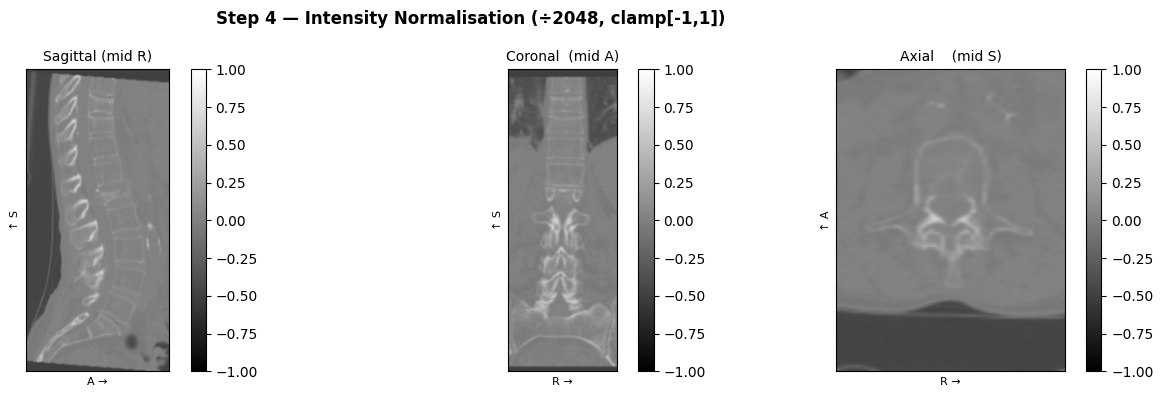

Normalised volume range: [-0.5054, 0.7537]
Mean: -0.0892  |  Std: 0.1946


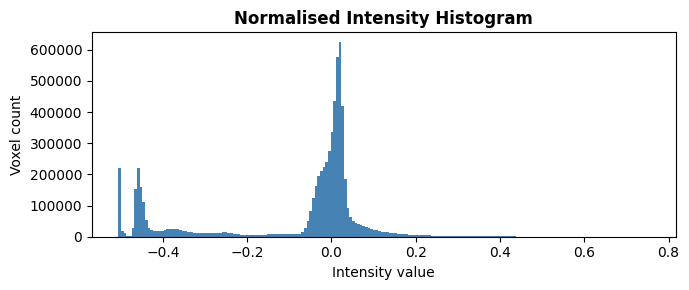

Preprocessing complete ✓
Final centroids (1mm voxel space): {16: (np.int64(64), np.int64(69), np.int64(298)), 17: (np.int64(64), np.int64(70), np.int64(274)), 18: (np.int64(63), np.int64(75), np.int64(248)), 19: (np.int64(63), np.int64(79), np.int64(218)), 20: (np.int64(62), np.int64(82), np.int64(192)), 21: (np.int64(61), np.int64(95), np.int64(166)), 22: (np.int64(59), np.int64(101), np.int64(134)), 23: (np.int64(58), np.int64(102), np.int64(103)), 24: (np.int64(57), np.int64(93), np.int64(75))}


In [8]:
# ── Step 4: Intensity normalisation — divide by 2048, clamp to [-1, 1] ───────
vol_step4 = np.clip(vol_step3 / CFG["intensity_divisor"], -1.0, 1.0)

nr, na, ns = vol_step4.shape
mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Step 4 — Intensity Normalisation (÷2048, clamp[-1,1])", fontsize=12, fontweight="bold")
for ax, (sl, lbl, xl, yl) in zip(axes, [
        (vol_step4[mid_r, :, :],  "Sagittal (mid R)", "A →", "↑ S"),
        (vol_step4[:, mid_a, :],  "Coronal  (mid A)", "R →", "↑ S"),
        (vol_step4[:, :, mid_s],  "Axial    (mid S)", "R →", "↑ A"),
]):
    im = ax.imshow(sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

print(f"Normalised volume range: [{vol_step4.min():.4f}, {vol_step4.max():.4f}]")
print(f"Mean: {vol_step4.mean():.4f}  |  Std: {vol_step4.std():.4f}")

# Histogram of normalised intensities
plt.figure(figsize=(7, 3))
plt.hist(vol_step4.ravel(), bins=200, color="steelblue", edgecolor="none")
plt.title("Normalised Intensity Histogram", fontweight="bold")
plt.xlabel("Intensity value"); plt.ylabel("Voxel count")
plt.tight_layout(); plt.show()

# Keep pre-processed copies for downstream use
preprocessed_vol  = vol_step4.astype(np.float32)
preprocessed_mask = mask_step2.astype(np.int16)
# Expose the correctly-mapped centroids for section 5
preprocessed_centroids = demo_centroids_1mm
print("Preprocessing complete ✓")
print(f"Final centroids (1mm voxel space): {preprocessed_centroids}")


## 5. Crop & Input Preparation Utilities

Three core functions used per vertebra:
1. **`crop_volume_around_centroid`** — extracts a `[128×128×96]` patch centred at the GT centroid (zero-pads near borders).
2. **`generate_gaussian_heatmap`** — builds a 3-D Gaussian centred at crop centre `(64, 64, 48)`.
3. **`extract_binary_mask`** — binarises the multi-label mask crop for a single vertebra.

## 🔍 Diagnostic: Understanding the Centroid Coordinate System

Before we can correctly crop around a centroid, we need to understand:
1. What coordinate space the JSON centroids are in (voxel? world-mm? which axis order?)
2. How that maps through reorientation + resampling

The VerSe JSON has a `"direction"` field (e.g. `["P","I","R"]`) — this tells us the **axis order** of the centroid coordinates.

DIAGNOSTIC: Centroid Coordinate System Analysis

1) JSON direction field: ['P', 'I', 'R']
   This means: X → P, Y → I, Z → R
   Raw JSON centroids:
     label  16:  X=   79.4  Y=   40.6  Z=   31.9
     label  17:  X=   79.4  Y=   63.1  Z=   31.8
     label  18:  X=   76.2  Y=   88.8  Z=   31.6
     label  19:  X=   70.8  Y=  117.3  Z=   31.1
     label  20:  X=   63.4  Y=  141.0  Z=   31.1
     label  21:  X=   53.0  Y=  167.7  Z=   30.3
     label  22:  X=   46.6  Y=  202.1  Z=   29.3
     label  23:  X=   46.8  Y=  235.2  Z=   28.5
     label  24:  X=   57.4  Y=  266.5  Z=   28.7

2) ORIGINAL volume (before reorientation):
   Shape: (161, 338, 61)
   Spacing (zooms): (np.float32(1.0), np.float32(1.0), np.float32(2.000296))
   Orientation (axcodes): ('P', 'I', 'R')  i.e. axis-0=P, axis-1=I, axis-2=R
   Affine:
[[ 3.57263708e-02 -2.85262855e-03  1.99901100e+00 -7.76940231e+01]
 [-9.96186848e-01  7.95440337e-02  7.16907652e-02  2.18001541e+02]
 [-7.95951681e-02 -9.96827272e-01  1.372230

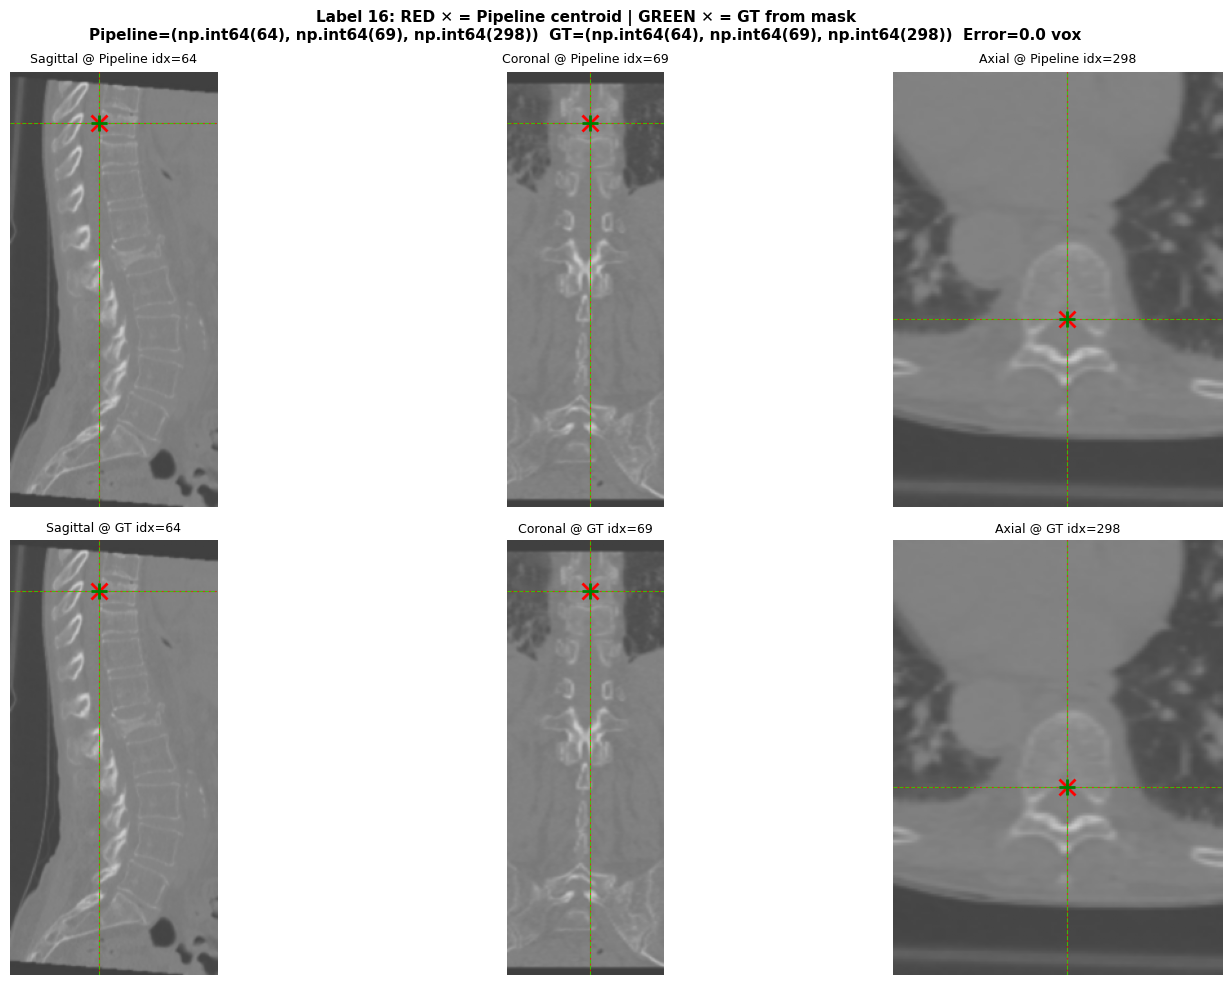

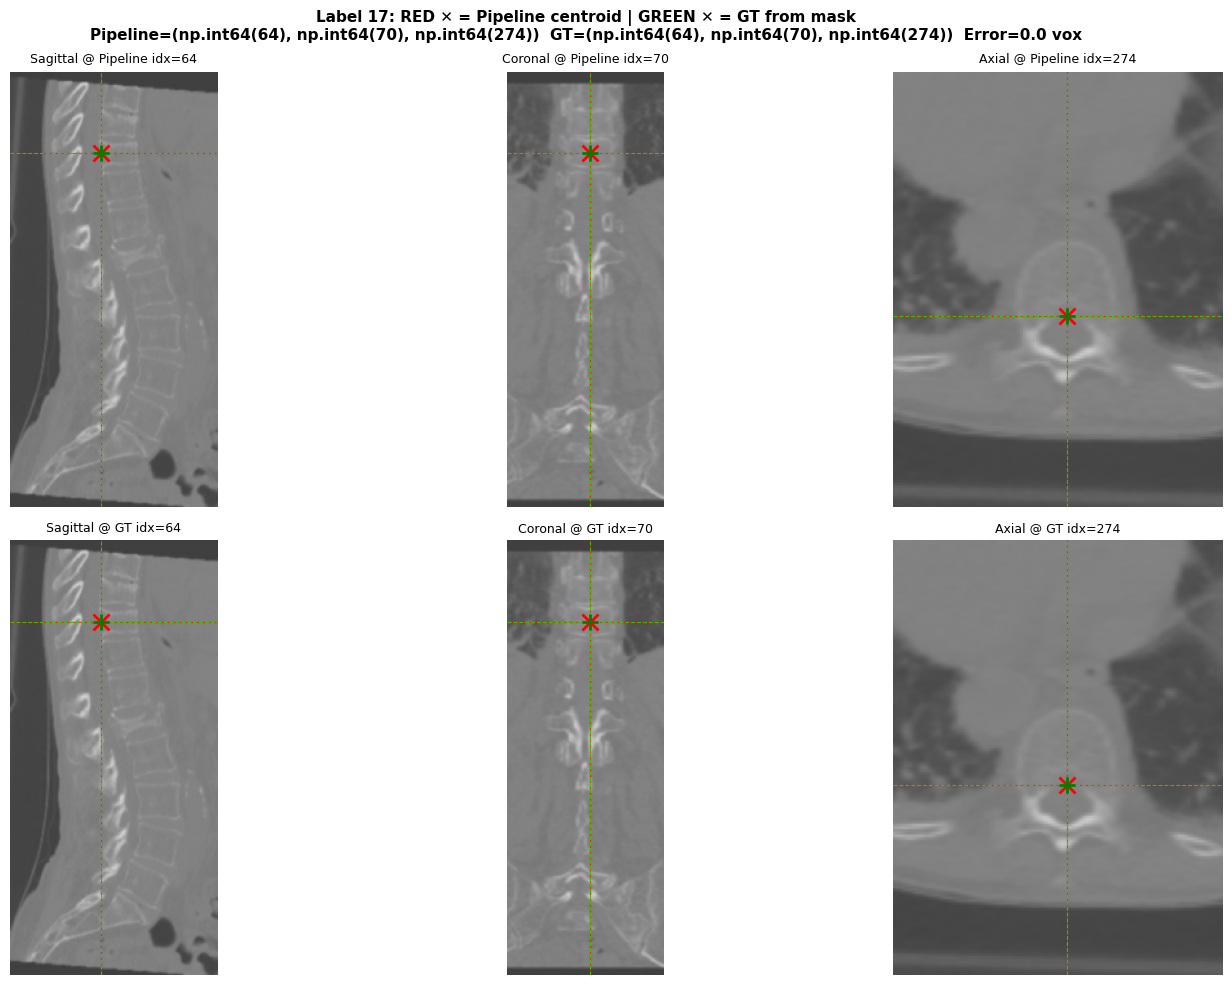

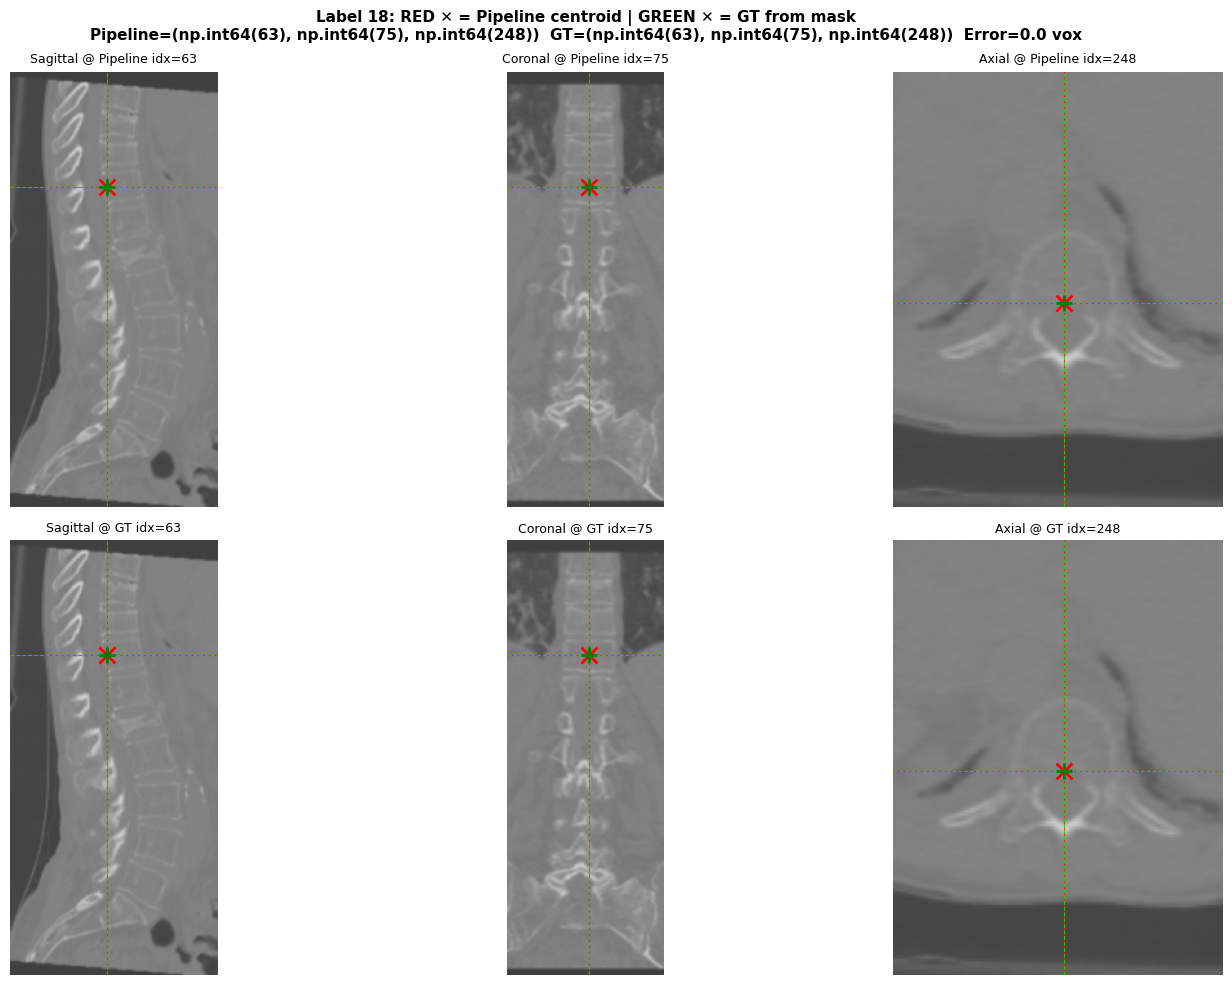


9) HYPOTHESIS: JSON values are voxel indices in the ORIGINAL image (PIR order)
   Direction = ['P', 'I', 'R'] → JSON (X,Y,Z) = (P_idx, I_idx, R_idx)
   Original orientation from NIfTI: ('P', 'I', 'R')
   Original shape: (161, 338, 61)
   We need to figure out which NIfTI axis corresponds to P, I, R...

   Direct indexing test on ORIGINAL volume:
     label 16: JSON=(79.4,40.6,31.9) → orig_vol[79,41,32] = 189 HU, orig_mask[79,41,32] = 16 ✓ MATCH!
     label 17: JSON=(79.4,63.1,31.8) → orig_vol[79,63,32] = -40 HU, orig_mask[79,63,32] = 17 ✓ MATCH!
     label 18: JSON=(76.2,88.8,31.6) → orig_vol[76,89,32] = 20 HU, orig_mask[76,89,32] = 18 ✓ MATCH!
     label 19: JSON=(70.8,117.3,31.1) → orig_vol[71,117,31] = 133 HU, orig_mask[71,117,31] = 19 ✓ MATCH!
     label 20: JSON=(63.4,141.0,31.1) → orig_vol[63,141,31] = 169 HU, orig_mask[63,141,31] = 20 ✓ MATCH!
     label 21: JSON=(53.0,167.7,30.3) → orig_vol[53,168,30] = 62 HU, orig_mask[53,168,30] = 21 ✓ MATCH!
     label 22: JSON=(46.6,202.1,

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  DIAGNOSTIC: What coordinate space are the JSON centroids actually in?         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# We need to compare TWO approaches for getting the voxel centroid:
#   A) Our current pipeline:  JSON (X,Y,Z) → world_to_voxel(ras_affine) → scale
#   B) Ground truth:          find np.where(mask == label) → mean voxel position

print("=" * 80)
print("DIAGNOSTIC: Centroid Coordinate System Analysis")
print("=" * 80)

# ── 1. Raw JSON values & direction metadata ──────────────────────────────────
raw_dir = demo["direction"]
raw_ctr = demo["centroids"]
print(f"\n1) JSON direction field: {raw_dir}")
print(f"   This means: X → {raw_dir[0]}, Y → {raw_dir[1]}, Z → {raw_dir[2]}")
print(f"   Raw JSON centroids:")
for lbl, (x, y, z) in sorted(raw_ctr.items()):
    print(f"     label {lbl:3d}:  X={x:7.1f}  Y={y:7.1f}  Z={z:7.1f}")

# ── 2. Original volume info (before any reorientation) ──────────────────────
print(f"\n2) ORIGINAL volume (before reorientation):")
print(f"   Shape: {vol_nib.shape}")
print(f"   Spacing (zooms): {vol_nib.header.get_zooms()[:3]}")
orig_ornt = nib.io_orientation(vol_nib.affine)
orig_axcodes = nib.orientations.ornt2axcodes(orig_ornt)
print(f"   Orientation (axcodes): {orig_axcodes}  i.e. axis-0={orig_axcodes[0]}, axis-1={orig_axcodes[1]}, axis-2={orig_axcodes[2]}")
print(f"   Affine:\n{vol_nib.affine}")

# ── 3. RAS volume info ──────────────────────────────────────────────────────
print(f"\n3) RAS-reoriented volume:")
print(f"   Shape: {vol_ras.shape}")
print(f"   Spacing (zooms): {np.array(vol_ras.header.get_zooms()[:3])}")
ras_axcodes = nib.orientations.ornt2axcodes(nib.io_orientation(vol_ras.affine))
print(f"   Orientation (axcodes): {ras_axcodes}")
print(f"   Affine:\n{vol_ras.affine}")

# ── 4. Resampled volume info ────────────────────────────────────────────────
print(f"\n4) Resampled (1mm) volume:")
print(f"   Shape: {preprocessed_vol.shape}")

# ── 5. KEY TEST: Are JSON values voxel indices or world-mm? ────────────────
print(f"\n5) KEY TEST — Are JSON (X,Y,Z) voxel indices in the ORIGINAL image?")
print(f"   If direction=['P','I','R'] and JSON gives voxel indices, then:")
print(f"   X indexes along 'P' axis, Y indexes along 'I' axis, Z indexes along 'R' axis")
print(f"   Original shape = {vol_nib.shape}, so max voxel index per axis = {tuple(s-1 for s in vol_nib.shape)}")
print(f"   Check: do JSON values fit within voxel range?")
for lbl, (x, y, z) in sorted(raw_ctr.items()):
    fits = (0 <= x < vol_nib.shape[0]) and (0 <= y < vol_nib.shape[1]) and (0 <= z < vol_nib.shape[2])
    print(f"     label {lbl}: ({x:.1f}, {y:.1f}, {z:.1f})  fits in shape {vol_nib.shape}? → {'YES ✓' if fits else 'NO ✗'}")

# Also check if they fit as world-mm via the affine
print(f"\n   Alternative: do JSON values make sense as WORLD-mm coordinates?")
for lbl, (x, y, z) in sorted(raw_ctr.items()):
    vox_from_world = world_to_voxel(vol_ras.affine, [x, y, z])
    in_bounds = np.all(vox_from_world >= 0) and np.all(vox_from_world < np.array(vol_ras.shape))
    print(f"     label {lbl}: world_to_voxel({x:.1f},{y:.1f},{z:.1f}) → {vox_from_world}  "
          f"in bounds {vol_ras.shape}? → {'YES ✓' if in_bounds else 'NO ✗'}")

# ── 6. GROUND TRUTH from mask ───────────────────────────────────────────────
print(f"\n6) GROUND TRUTH: Where does each label actually appear in the mask?")
print(f"   (computed from the PREPROCESSED mask at 1mm spacing)")

mask_data = preprocessed_mask
gt_centroids = {}
unique_labels = np.unique(mask_data)
unique_labels = unique_labels[unique_labels > 0]  # skip background
print(f"   Unique non-zero labels in mask: {list(unique_labels.astype(int))}")

for lbl_val in unique_labels:
    lbl_int = int(lbl_val)
    coords = np.array(np.where(mask_data == lbl_val))  # shape (3, N)
    centroid_from_mask = coords.mean(axis=1)
    n_voxels = coords.shape[1]
    gt_centroids[lbl_int] = tuple(np.round(centroid_from_mask).astype(int))
    print(f"   label {lbl_int}: mask centroid = {gt_centroids[lbl_int]}  "
          f"(from {n_voxels} voxels, "
          f"range i=[{coords[0].min()}-{coords[0].max()}], "
          f"j=[{coords[1].min()}-{coords[1].max()}], "
          f"k=[{coords[2].min()}-{coords[2].max()}])")

# Also compute ground truth on the ORIGINAL (non-reoriented) mask
print(f"\n   GROUND TRUTH on the ORIGINAL mask (before reorientation):")
if mask_nib is not None:
    orig_mask_data = mask_nib.get_fdata()
    for lbl_val in unique_labels:
        lbl_int = int(lbl_val)
        coords_orig = np.array(np.where(orig_mask_data == lbl_val))
        if coords_orig.shape[1] > 0:
            centroid_orig = coords_orig.mean(axis=1)
            print(f"   label {lbl_int}: ORIGINAL mask centroid = "
                  f"({centroid_orig[0]:.1f}, {centroid_orig[1]:.1f}, {centroid_orig[2]:.1f})  "
                  f"shape={orig_mask_data.shape}")
else:
    print("   (no mask available)")

# ── 7. COMPARISON: pipeline centroid vs ground truth ─────────────────────────
print(f"\n7) COMPARISON: Pipeline centroid vs Ground-truth mask centroid (1mm space)")
print(f"   {'Label':>6}  {'Pipeline (i,j,k)':>22}  {'GT from mask (i,j,k)':>22}  {'Euclidean error (vox)':>22}")
print(f"   {'─'*6}  {'─'*22}  {'─'*22}  {'─'*22}")
for lbl in sorted(set(list(preprocessed_centroids.keys())) & set(list(gt_centroids.keys()))):
    p = np.array(preprocessed_centroids[lbl])
    g = np.array(gt_centroids[lbl])
    err = np.linalg.norm(p - g)
    print(f"   {lbl:6d}  {str(tuple(p)):>22}  {str(tuple(g)):>22}  {err:>22.1f}")

# ── 8. VISUAL: Crosshairs on axial slice ─────────────────────────────────────
print(f"\n8) Visual comparison — crosshairs on preprocessed volume")
# Pick the first available centroid that has a mask match
demo_labels = sorted(set(list(preprocessed_centroids.keys())) & set(list(gt_centroids.keys())))
if demo_labels:
    for pick_label in demo_labels[:3]:  # show up to 3 vertebrae
        p = np.array(preprocessed_centroids[pick_label])
        g = np.array(gt_centroids[pick_label])

        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"Label {pick_label}: RED ✕ = Pipeline centroid | GREEN ✕ = GT from mask\n"
                     f"Pipeline={tuple(p)}  GT={tuple(g)}  Error={np.linalg.norm(p-g):.1f} vox",
                     fontsize=11, fontweight="bold")

        vol = preprocessed_vol
        msk = preprocessed_mask

        # Row 0: slices at PIPELINE centroid
        for col, (ax_idx, plane, xlabel, ylabel) in enumerate([
            (0, "Sagittal", "A →", "↑ S"),
            (1, "Coronal",  "R →", "↑ S"),
            (2, "Axial",    "R →", "↑ A"),
        ]):
            ax = axes[0, col]
            if ax_idx == 0:
                sl = vol[p[0], :, :]
            elif ax_idx == 1:
                sl = vol[:, p[1], :]
            else:
                sl = vol[:, :, p[2]]
            ax.imshow(sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
            # Pipeline centroid cross (red)
            cross_coords = [(p[1], p[2]), (p[0], p[2]), (p[0], p[1])][col]
            ax.axhline(cross_coords[1], color="red", lw=0.8, alpha=0.7)
            ax.axvline(cross_coords[0], color="red", lw=0.8, alpha=0.7)
            ax.plot(cross_coords[0], cross_coords[1], "rx", markersize=12, markeredgewidth=2)
            # GT centroid cross (green)
            gt_cross = [(g[1], g[2]), (g[0], g[2]), (g[0], g[1])][col]
            ax.axhline(gt_cross[1], color="lime", lw=0.8, alpha=0.7, linestyle="--")
            ax.axvline(gt_cross[0], color="lime", lw=0.8, alpha=0.7, linestyle="--")
            ax.plot(gt_cross[0], gt_cross[1], "g+", markersize=12, markeredgewidth=2)
            ax.set_title(f"{plane} @ Pipeline idx={p[ax_idx]}", fontsize=9)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.axis("off")

        # Row 1: slices at GT centroid
        for col, (ax_idx, plane, xlabel, ylabel) in enumerate([
            (0, "Sagittal", "A →", "↑ S"),
            (1, "Coronal",  "R →", "↑ S"),
            (2, "Axial",    "R →", "↑ A"),
        ]):
            ax = axes[1, col]
            if ax_idx == 0:
                sl = vol[g[0], :, :]
            elif ax_idx == 1:
                sl = vol[:, g[1], :]
            else:
                sl = vol[:, :, g[2]]
            ax.imshow(sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
            # Pipeline centroid cross (red)
            cross_coords = [(p[1], p[2]), (p[0], p[2]), (p[0], p[1])][col]
            ax.axhline(cross_coords[1], color="red", lw=0.8, alpha=0.7)
            ax.axvline(cross_coords[0], color="red", lw=0.8, alpha=0.7)
            ax.plot(cross_coords[0], cross_coords[1], "rx", markersize=12, markeredgewidth=2)
            # GT centroid cross (green)
            gt_cross = [(g[1], g[2]), (g[0], g[2]), (g[0], g[1])][col]
            ax.axhline(gt_cross[1], color="lime", lw=0.8, alpha=0.7, linestyle="--")
            ax.axvline(gt_cross[0], color="lime", lw=0.8, alpha=0.7, linestyle="--")
            ax.plot(gt_cross[0], gt_cross[1], "g+", markersize=12, markeredgewidth=2)
            ax.set_title(f"{plane} @ GT idx={g[ax_idx]}", fontsize=9)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.axis("off")

        axes[0, 0].set_ylabel("Sliced at\nPIPELINE centroid", fontsize=10, color="red", fontweight="bold")
        axes[1, 0].set_ylabel("Sliced at\nGT centroid", fontsize=10, color="lime", fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("  ⚠ No overlapping labels between pipeline centroids and mask — cannot compare.")

# ── 9. HYPOTHESIS TEST: Are JSON values voxel indices in ORIGINAL PIR space? ─
print(f"\n9) HYPOTHESIS: JSON values are voxel indices in the ORIGINAL image (PIR order)")
print(f"   Direction = {raw_dir} → JSON (X,Y,Z) = (P_idx, I_idx, R_idx)")
print(f"   Original orientation from NIfTI: {orig_axcodes}")
print(f"   Original shape: {vol_nib.shape}")
print(f"   We need to figure out which NIfTI axis corresponds to P, I, R...")

# Map direction letters to their RAS-equivalents
# P(osterior) is the negative of A(nterior)
# I(nferior)  is the negative of S(uperior)
# R(ight)     is R
# So direction ["P","I","R"] means the image was stored as (P→, I→, R→)
# which in RAS terms is:  axis-0 goes in -A direction,
#                          axis-1 goes in -S direction,
#                          axis-2 goes in +R direction
# i.e. the original orientation is (P, I, R) = (-A, -S, R)

# If JSON gives voxel indices in PIR order, we can directly index the original volume:
print(f"\n   Direct indexing test on ORIGINAL volume:")
if mask_nib is not None:
    orig_vol_data = vol_nib.get_fdata()
    orig_mask_data = mask_nib.get_fdata()
    for lbl, (x, y, z) in sorted(raw_ctr.items()):
        ix, iy, iz = int(round(x)), int(round(y)), int(round(z))
        # Clamp
        ix = max(0, min(ix, orig_vol_data.shape[0]-1))
        iy = max(0, min(iy, orig_vol_data.shape[1]-1))
        iz = max(0, min(iz, orig_vol_data.shape[2]-1))
        vol_val = orig_vol_data[ix, iy, iz]
        mask_val = orig_mask_data[ix, iy, iz]
        print(f"     label {lbl}: JSON=({x:.1f},{y:.1f},{z:.1f}) → "
              f"orig_vol[{ix},{iy},{iz}] = {vol_val:.0f} HU, "
              f"orig_mask[{ix},{iy},{iz}] = {int(mask_val)} "
              f"{'✓ MATCH!' if int(mask_val) == lbl else '✗ mismatch'}")

    # Also test: do they index correctly in world_to_voxel(original affine)?
    print(f"\n   Test: treat JSON as WORLD-mm, convert via ORIGINAL affine:")
    for lbl, (x, y, z) in sorted(raw_ctr.items()):
        vox_orig = world_to_voxel(vol_nib.affine, [x, y, z])
        vox_orig_clamped = np.clip(vox_orig, 0, np.array(vol_nib.shape[:3]) - 1)
        mask_val = orig_mask_data[vox_orig_clamped[0], vox_orig_clamped[1], vox_orig_clamped[2]]
        print(f"     label {lbl}: world_to_voxel(orig_affine, ({x:.1f},{y:.1f},{z:.1f})) → "
              f"{tuple(vox_orig)} → mask={int(mask_val)} "
              f"{'✓ MATCH!' if int(mask_val) == lbl else '✗ mismatch'}")

    # And: world_to_voxel with RAS affine
    print(f"\n   Test: treat JSON as WORLD-mm, convert via RAS affine (current pipeline):")
    ras_mask = mask_ras.get_fdata() if mask_ras is not None else None
    for lbl, (x, y, z) in sorted(raw_ctr.items()):
        vox_ras = world_to_voxel(vol_ras.affine, [x, y, z])
        vox_ras_clamped = np.clip(vox_ras, 0, np.array(vol_ras.shape[:3]) - 1)
        if ras_mask is not None:
            mask_val = ras_mask[vox_ras_clamped[0], vox_ras_clamped[1], vox_ras_clamped[2]]
        else:
            mask_val = -1
        print(f"     label {lbl}: world_to_voxel(ras_affine, ({x:.1f},{y:.1f},{z:.1f})) → "
              f"{tuple(vox_ras)} → mask={int(mask_val)} "
              f"{'✓ MATCH!' if int(mask_val) == lbl else '✗ mismatch'}")

print("\n" + "=" * 80)
print("END OF DIAGNOSTIC — Check which method gives '✓ MATCH!' to identify the")
print("correct coordinate interpretation, then fix the pipeline accordingly.")
print("=" * 80)

Vertebra label    : 16
Centroid (vox)    : (np.int64(64), np.int64(69), np.int64(298))
Crop offset       : (0, 5, 250)
CT crop shape     : (128, 128, 96)  range [-0.504, 0.628]
Heatmap peak      : 1.0000  at index (np.int64(64), np.int64(64), np.int64(48))
Binary mask shape : (128, 128, 96)  foreground voxels: 28220


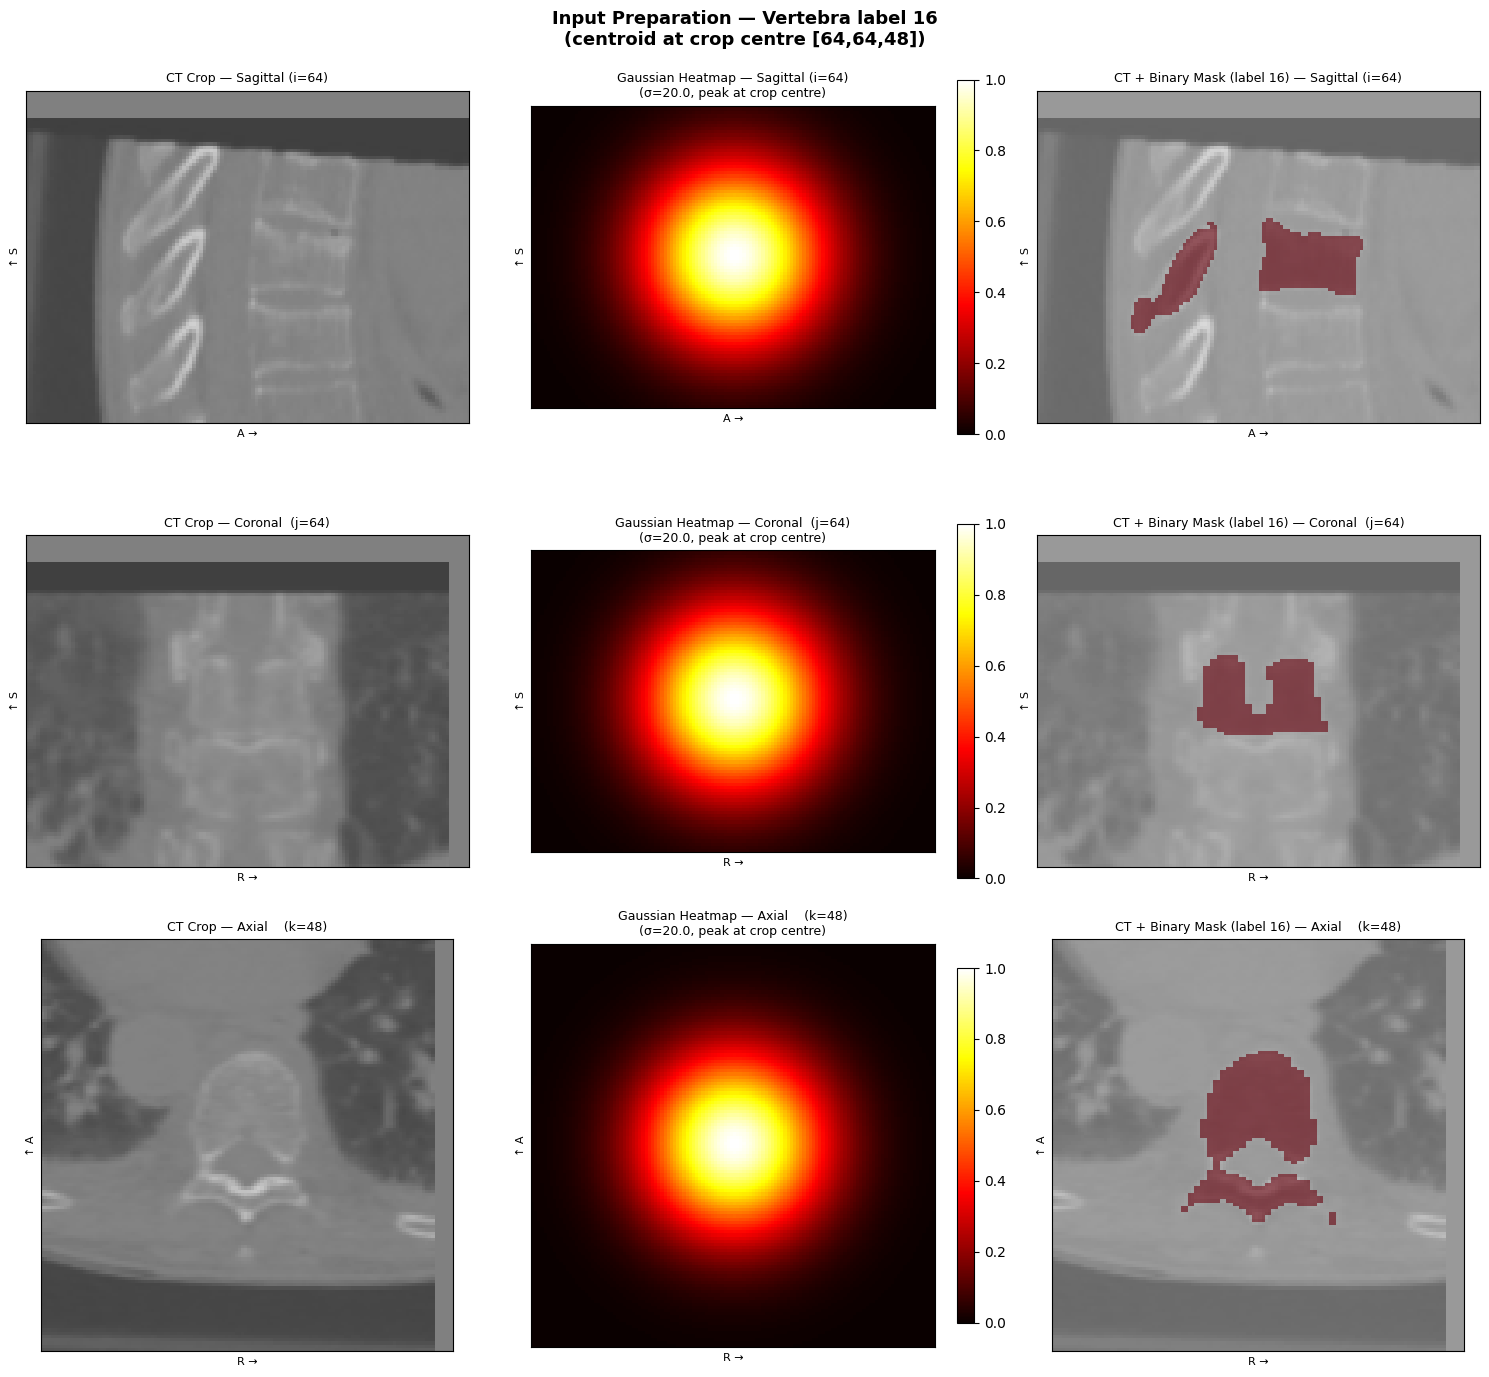

In [10]:
def crop_volume_around_centroid(volume, centroid_vox, crop_size=(128, 128, 96)):
    """
    Crop a 3-D volume centred on `centroid_vox` (voxel coordinates).
    Zero-pads if the ROI extends outside the volume bounds.

    Parameters
    ----------
    volume       : np.ndarray  shape (R, A, S)  — RAS-oriented, 1mm isotropic
    centroid_vox : tuple/array (ci, cj, ck) — integer voxel indices in the volume
    crop_size    : tuple (si, sj, sk)

    Returns
    -------
    crop    : np.ndarray  shape crop_size
    offset  : tuple (i0, j0, k0) — top-left corner of the crop in volume coords
    """
    ci, cj, ck = [int(round(c)) for c in centroid_vox]
    si, sj, sk = crop_size
    hi, hj, hk = si // 2, sj // 2, sk // 2

    # Desired extent in the original volume (may be negative / out-of-bounds)
    i0, j0, k0 = ci - hi, cj - hj, ck - hk
    i1, j1, k1 = i0 + si, j0 + sj, k0 + sk

    vol_i, vol_j, vol_k = volume.shape

    # Clamp to valid volume bounds
    is_ = max(i0, 0); ie = min(i1, vol_i)
    js  = max(j0, 0); je = min(j1, vol_j)
    ks  = max(k0, 0); ke = min(k1, vol_k)

    # Where to paste inside the output crop
    pi0 = is_ - i0;  pi1 = pi0 + (ie - is_)
    pj0 = js  - j0;  pj1 = pj0 + (je - js)
    pk0 = ks  - k0;  pk1 = pk0 + (ke - ks)

    crop = np.zeros(crop_size, dtype=volume.dtype)
    crop[pi0:pi1, pj0:pj1, pk0:pk1] = volume[is_:ie, js:je, ks:ke]
    return crop, (i0, j0, k0)


def generate_gaussian_heatmap(crop_size=(128, 128, 96), sigma=20.0):
    """
    3-D Gaussian heatmap always centred at the exact crop centre (hi, hj, hk).

    H(i,j,k) = exp( -[(i-hi)^2 + (j-hj)^2 + (k-hk)^2] / (2*sigma^2) )

    The heatmap peak (value=1) is at the crop centre, which corresponds to the
    GT centroid position — so it tells the U-Net *where* to focus.
    """
    si, sj, sk = crop_size
    hi, hj, hk = si // 2, sj // 2, sk // 2
    ii = np.arange(si) - hi
    jj = np.arange(sj) - hj
    kk = np.arange(sk) - hk
    grid_i, grid_j, grid_k = np.meshgrid(ii, jj, kk, indexing="ij")
    heatmap = np.exp(-(grid_i**2 + grid_j**2 + grid_k**2) / (2.0 * sigma**2))
    return heatmap.astype(np.float32)


def extract_binary_mask(mask_crop, target_label):
    """Convert a multi-label mask crop to binary (1 = target vertebra, 0 = rest)."""
    return (mask_crop == target_label).astype(np.float32)


# ── Demo: run utilities on the first vertebra ──────────────────────────────────
if not preprocessed_centroids:
    # Fallback: centre of volume
    preprocessed_centroids = {0: tuple(s // 2 for s in preprocessed_vol.shape)}

first_label   = sorted(preprocessed_centroids.keys())[0]
centroid_vox  = preprocessed_centroids[first_label]   # already in 1mm voxel space

ct_crop,    offset = crop_volume_around_centroid(preprocessed_vol,  centroid_vox, CFG["crop_size"])
mk_crop,    _      = crop_volume_around_centroid(preprocessed_mask, centroid_vox, CFG["crop_size"])
heatmap             = generate_gaussian_heatmap(CFG["crop_size"], CFG["heatmap_sigma"])
binary_mask         = extract_binary_mask(mk_crop, first_label)

si, sj, sk = CFG["crop_size"]   # (128, 128, 96)
hi, hj, hk = si // 2, sj // 2, sk // 2   # crop centre = centroid location

print(f"Vertebra label    : {first_label}")
print(f"Centroid (vox)    : {centroid_vox}")
print(f"Crop offset       : {offset}")
print(f"CT crop shape     : {ct_crop.shape}  range [{ct_crop.min():.3f}, {ct_crop.max():.3f}]")
print(f"Heatmap peak      : {heatmap.max():.4f}  at index {np.unravel_index(heatmap.argmax(), heatmap.shape)}")
print(f"Binary mask shape : {binary_mask.shape}  foreground voxels: {int(binary_mask.sum())}")

# ── Three-view visualisation: sagittal / coronal / axial ─────────────────────
# Crop axes match the RAS-reoriented volume axes:
#   axis-0 (i) = R direction  →  fix i=hi for sagittal
#   axis-1 (j) = A direction  →  fix j=hj for coronal
#   axis-2 (k) = S direction  →  fix k=hk for axial

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
fig.suptitle(f"Input Preparation — Vertebra label {first_label}\n"
             f"(centroid at crop centre [{hi},{hj},{hk}])",
             fontsize=13, fontweight="bold")

view_defs = [
    # (slice of ct_crop, slice of heatmap, slice of binary_mask, view title, xlabel, ylabel)
    (ct_crop[hi, :, :],    heatmap[hi, :, :],    binary_mask[hi, :, :],
     f"Sagittal (i={hi})",  "A →", "↑ S"),
    (ct_crop[:, hj, :],    heatmap[:, hj, :],    binary_mask[:, hj, :],
     f"Coronal  (j={hj})",  "R →", "↑ S"),
    (ct_crop[:, :, hk],    heatmap[:, :, hk],    binary_mask[:, :, hk],
     f"Axial    (k={hk})",  "R →", "↑ A"),
]

for row_idx, (ct_sl, hm_sl, bm_sl, view_title, xl, yl) in enumerate(view_defs):
    # --- column 0: CT crop slice ---
    axes[row_idx, 0].imshow(ct_sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
    axes[row_idx, 0].set_title(f"CT Crop — {view_title}", fontsize=9)
    axes[row_idx, 0].set_xlabel(xl, fontsize=8)
    axes[row_idx, 0].set_ylabel(yl, fontsize=8)
    axes[row_idx, 0].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

    # --- column 1: Gaussian heatmap ---
    im_hm = axes[row_idx, 1].imshow(hm_sl.T, cmap="hot", origin="lower", vmin=0, vmax=1)
    axes[row_idx, 1].set_title(f"Gaussian Heatmap — {view_title}\n"
                                f"(σ={CFG['heatmap_sigma']}, peak at crop centre)",
                                fontsize=9)
    axes[row_idx, 1].set_xlabel(xl, fontsize=8)
    axes[row_idx, 1].set_ylabel(yl, fontsize=8)
    axes[row_idx, 1].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)
    plt.colorbar(im_hm, ax=axes[row_idx, 1], fraction=0.04)

    # --- column 2: CT + binary mask overlay ---
    axes[row_idx, 2].imshow(ct_sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1, alpha=0.8)
    if bm_sl.max() > 0:
        axes[row_idx, 2].imshow(
            np.ma.masked_where(bm_sl == 0, bm_sl).T,
            cmap="Reds", origin="lower", vmin=0, vmax=1, alpha=0.6)
    axes[row_idx, 2].set_title(f"CT + Binary Mask (label {first_label}) — {view_title}",
                                fontsize=9)
    axes[row_idx, 2].set_xlabel(xl, fontsize=8)
    axes[row_idx, 2].set_ylabel(yl, fontsize=8)
    axes[row_idx, 2].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()

if binary_mask.sum() == 0:
    print(f"⚠  No foreground voxels for label {first_label} in this crop. "
          f"Check centroid mapping or mask labels: {np.unique(preprocessed_mask)}")


## 6. Dataset Class

`VertebraeDataset` expands each subject into **one sample per vertebra**.  
Each sample is a dict with:
- `ct_crop`     → `Tensor[1, 128, 128, 96]`
- `heatmap`     → `Tensor[1, 128, 128, 96]`
- `input`       → `Tensor[2, 128, 128, 96]`  (channel-wise stack of the two above)
- `binary_mask` → `Tensor[1, 128, 128, 96]`
- `label`       → `int`
- `subject`     → `str`

In [11]:
def full_preprocess(vol_nib, mask_nib=None, target_spacing=1.0, sigma=0.75, divisor=2048.0):
    """
    Full preprocessing pipeline: reorient → resample → smooth → normalise.
    mask_nib may be None.
    Returns:
        vol_n        : np.ndarray float32 — normalised, 1mm isotropic, RAS
        mask_out     : np.ndarray int16   — resampled labels (zeros if no mask)
        ras_affine   : np.ndarray (4,4)   — affine of the RAS-reoriented volume
                       (needed to map world-mm centroids → voxel indices)
        zooms        : np.ndarray (3,)    — spacing BEFORE resampling (for coord scaling)
        orig_affine  : np.ndarray (4,4)   — original image affine
    """
    # Reorient volume to RAS+
    vol_ras    = reorient_to_ras(vol_nib)
    ras_affine = vol_ras.affine.copy()
    zooms      = np.array(vol_ras.header.get_zooms()[:3], dtype=np.float64)
    vol_data   = vol_ras.get_fdata(dtype=np.float32)

    # Resample to 1mm isotropic
    vol_r = resample_volume(vol_data, zooms, target_spacing, order=1)

    # Smooth + normalise
    vol_s = gaussian_filter(vol_r, sigma=sigma)
    vol_n = np.clip(vol_s / divisor, -1.0, 1.0).astype(np.float32)

    # Mask (optional)
    if mask_nib is not None:
        mask_ras  = reorient_to_ras(mask_nib)
        mask_data = mask_ras.get_fdata().astype(np.int16)
        mask_r    = resample_volume(mask_data, zooms, target_spacing, order=0)
        mask_out  = mask_r.astype(np.int16)
    else:
        mask_out = np.zeros(vol_n.shape, dtype=np.int16)

    return vol_n, mask_out, ras_affine, zooms, vol_nib.affine


def centroids_to_voxel_1mm(raw_centroids, original_affine, ras_affine, original_zooms, target_spacing=1.0):
    """
    Convert JSON original voxel centroids → integer voxel indices in the
    1mm-isotropic, RAS-reoriented volume.
    """
    scale = original_zooms / target_spacing
    inv_affine = np.linalg.inv(ras_affine)
    result = {}
    for label, (vx, vy, vz) in raw_centroids.items():
        world_pt = original_affine @ np.array([vx, vy, vz, 1.0])
        ras_vox = inv_affine[:3, :3] @ world_pt[:3] + inv_affine[:3, 3]
        vox_1mm = np.round(ras_vox * scale).astype(int)
        result[label] = tuple(vox_1mm)
    return result

class VertebraeDataset(Dataset):
    """
    One item per (subject, vertebra) pair.
    Saves and loads crops from disk to prevent RAM Out-Of-Memory (OOM) crashes.
    """
    def __init__(self, csv_path, split, crop_size=(128, 128, 96),
                 heatmap_sigma=20.0, augment=None, 
                 cache_base_dir="/kaggle/working/verse_patches",
                 prebuilt_dir="/kaggle/input/datasets/ahmed226/stage3-preprocessed-data"):
        self.crop_size     = crop_size
        self.heatmap_sigma = heatmap_sigma
        self.augment       = augment
        
        # Create cache directory for this split (for newly processed files)
        self.cache_dir = os.path.join(cache_base_dir, split)
        os.makedirs(self.cache_dir, exist_ok=True)
        
        self.prebuilt_dir = os.path.join(prebuilt_dir, split)

        df       = pd.read_csv(csv_path)
        df_split = df[df["type"] == split].reset_index(drop=True)

        self.samples = []
        total_subjects = len(df_split)
        
        print(f"\nInitializing {split.upper()} dataset ({total_subjects} subjects)...")
        for i, (_, row) in enumerate(df_split.iterrows(), 1):
            subj_name = row.get("name", "?")
            print(f"  [{i}/{total_subjects}] Processing {subj_name}... ", end="", flush=True)
            
            try:
                if not _is_valid_path(row.get("image_path")) or not _is_valid_path(row.get("centroid_json_path")):
                    raise ValueError("Paths are missing/NaN")

                mask_nib_ = nib.load(str(row["mask_path"])) if _is_valid_path(row.get("mask_path")) else None
                _, raw_centroids = parse_centroid_json(str(row["centroid_json_path"]))

                # Check if we already cached this subject's patches (either in prebuilt data or local cache)
                needs_processing = False
                subject_patch_paths = {}
                
                for label in raw_centroids.keys():
                    prebuilt_path = os.path.join(self.prebuilt_dir, f"{subj_name}_lbl{label}.npz")
                    local_path = os.path.join(self.cache_dir, f"{subj_name}_lbl{label}.npz")
                    
                    if os.path.exists(prebuilt_path):
                        subject_patch_paths[label] = prebuilt_path
                    elif os.path.exists(local_path):
                        subject_patch_paths[label] = local_path
                    else:
                        needs_processing = True
                        subject_patch_paths[label] = local_path

                if needs_processing:
                    # ONLY load massive arrays if crops don't exist yet
                    vol_nib_ = nib.load(str(row["image_path"]))
                    vol_pp, mask_pp, ras_affine, zooms, orig_affine = full_preprocess(vol_nib_, mask_nib_)
                    centroids_1mm = centroids_to_voxel_1mm(raw_centroids, orig_affine, ras_affine, zooms)

                    vol_shape = np.array(vol_pp.shape)
                    
                    for label, vox in centroids_1mm.items():
                        if mask_nib_ is not None and np.any(mask_pp == label):
                            coords = np.array(np.where(mask_pp == label))
                            vox = tuple(np.round(coords.mean(axis=1)).astype(int))
                            
                        vox_clamped = tuple(int(np.clip(v, 0, vol_shape[ax] - 1)) for ax, v in enumerate(vox))
                        
                        # Extract the patch and save to local disk
                        ct_crop, _ = crop_volume_around_centroid(vol_pp, vox_clamped, self.crop_size)
                        mk_crop, _ = crop_volume_around_centroid(mask_pp, vox_clamped, self.crop_size)
                        
                        np.savez_compressed(subject_patch_paths[label], ct_crop=ct_crop, mk_crop=mk_crop)

                    # Free big arrays from memory explicitly
                    del vol_pp, mask_pp, vol_nib_

                # Register the files in the dataset
                vertebrae_count = 0
                for label, patch_path in subject_patch_paths.items():
                    if os.path.exists(patch_path):
                        self.samples.append({
                            "patch_path": patch_path,
                            "label":      label,
                            "subject":    subj_name,
                            "has_mask":   mask_nib_ is not None,
                        })
                        vertebrae_count += 1
                
                print(f"✓ Ready ({vertebrae_count} patches)")

            except Exception as e:
                print(f"✗ Failed: {e}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        
        # Load the small patch from disk instead of RAM
        data = np.load(s["patch_path"])
        ct_crop = data["ct_crop"]
        mk_crop = data["mk_crop"]
        
        heatmap     = generate_gaussian_heatmap(self.crop_size, self.heatmap_sigma)
        binary_mask = extract_binary_mask(mk_crop, s["label"])

        if self.augment is not None:
            ct_crop, binary_mask = self.augment(ct_crop, binary_mask)

        ct_t  = torch.from_numpy(ct_crop[None])
        hm_t  = torch.from_numpy(heatmap[None])
        bm_t  = torch.from_numpy(binary_mask[None])
        inp_t = torch.cat([ct_t, hm_t], dim=0)

        return {
            "input":       inp_t,
            "ct_crop":     ct_t,
            "heatmap":     hm_t,
            "binary_mask": bm_t,
            "label":       s["label"],
            "subject":     s["subject"],
            "has_mask":    s["has_mask"],
        }


# ── Instantiate datasets ─────────────────────────────────────────────────────
csv_path = CFG["csv_path"]
train_ds = VertebraeDataset(csv_path, split="train", crop_size=CFG["crop_size"],
                            heatmap_sigma=CFG["heatmap_sigma"])
val_ds   = VertebraeDataset(csv_path, split="val",   crop_size=CFG["crop_size"],
                            heatmap_sigma=CFG["heatmap_sigma"])
test_ds  = VertebraeDataset(csv_path, split="test",  crop_size=CFG["crop_size"],
                            heatmap_sigma=CFG["heatmap_sigma"])

print(f"\n--- Total Dataset Samples (Vertebrae Patches) ---")
print(f"Train samples : {len(train_ds)}")
print(f"Val   samples : {len(val_ds)}")
print(f"Test  samples : {len(test_ds)}")

_demo_ds = next((ds for ds in [train_ds, val_ds, test_ds] if len(ds) > 0), None)
if _demo_ds is not None:
    print(f"\nExtracting sample patch...")
    sample = _demo_ds[0]
    print(f"Sample keys : {list(sample.keys())}")
    print(f"  input       : {sample['input'].shape}  dtype={sample['input'].dtype}")
    print(f"  ct_crop     : {sample['ct_crop'].shape}")
    print(f"  heatmap     : {sample['heatmap'].shape}")
    print(f"  binary_mask : {sample['binary_mask'].shape}")
    print(f"  label       : {sample['label']}")
    print(f"  subject     : {sample['subject']}")
    print(f"  has_mask    : {sample['has_mask']}")
    fg = sample['binary_mask'].sum().item()
    print(f"  foreground voxels in mask: {int(fg)}"
          + ("  ⚠ empty!" if fg == 0 else "  ✓"))
else:
    print("No samples loaded (check file paths in CSV).")


Initializing TRAIN dataset (76 subjects)...
  [1/76] Processing verse004... ✓ Ready (9 patches)
  [2/76] Processing verse006... ✓ Ready (2 patches)
  [3/76] Processing verse007... ✓ Ready (7 patches)
  [4/76] Processing verse008... ✓ Ready (6 patches)
  [5/76] Processing verse009... ✓ Ready (16 patches)
  [6/76] Processing verse014... ✓ Ready (5 patches)
  [7/76] Processing verse015... ✓ Ready (6 patches)
  [8/76] Processing verse031... ✓ Ready (5 patches)
  [9/76] Processing verse033... ✓ Ready (18 patches)
  [10/76] Processing verse034... ✓ Ready (8 patches)
  [11/76] Processing verse036... ✓ Ready (4 patches)
  [12/76] Processing verse043... ✓ Ready (16 patches)
  [13/76] Processing verse046... ✓ Ready (5 patches)
  [14/76] Processing verse048... ✓ Ready (4 patches)
  [15/76] Processing verse051... ✓ Ready (8 patches)
  [16/76] Processing verse056... ✓ Ready (7 patches)
  [17/76] Processing verse060... ✓ Ready (6 patches)
  [18/76] Processing verse061... ✓ Ready (8 patches)
  [19/7

## 7. Data Augmentation Pipeline

Applied **jointly** to `ct_crop` and `binary_mask` on-the-fly.  
The Gaussian heatmap is **never spatially augmented** (it's always centred at crop centre).

Augmentation pipeline created ✓


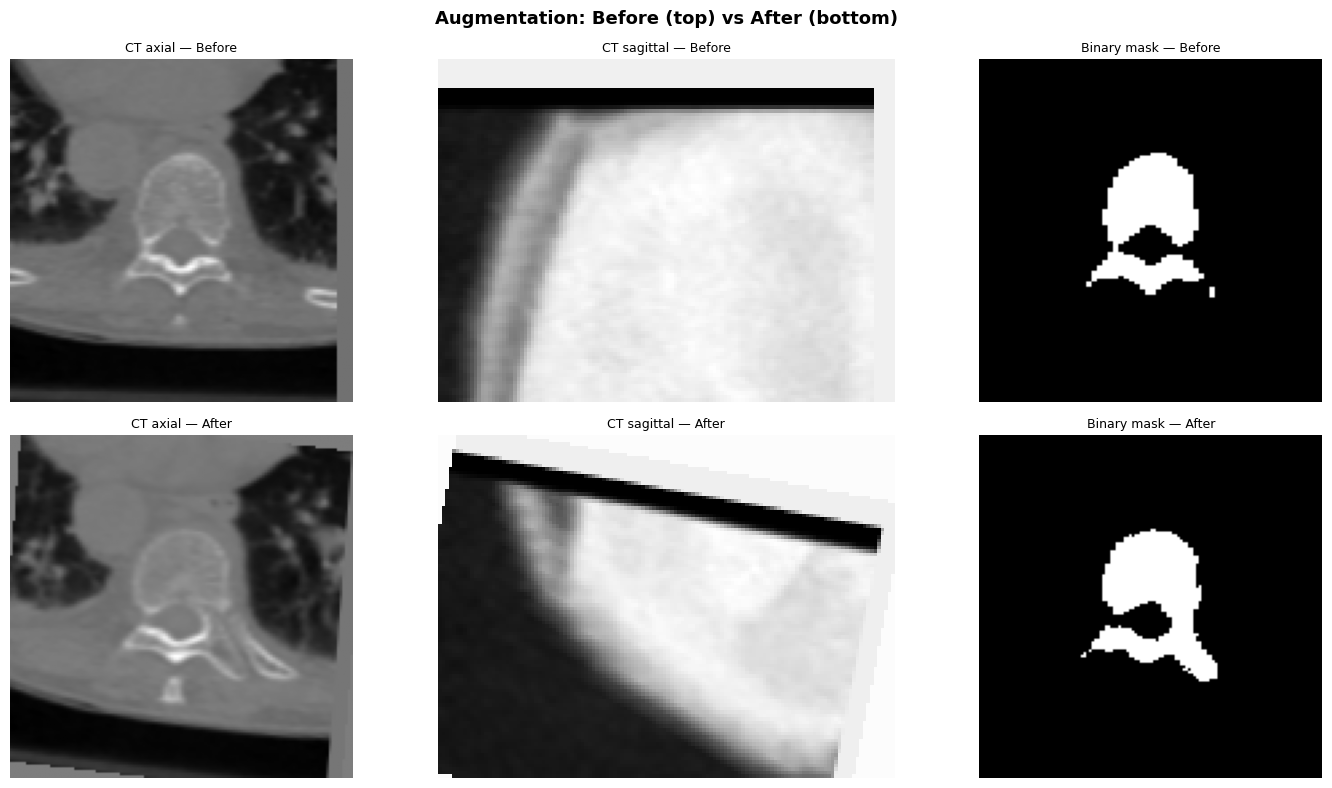

Augmentation attached to train dataset ✓


In [12]:
class Augment3D:
    """
    On-the-fly 3-D augmentation.
    Right now, only applying Intensity changes to preserve Heatmap alignment 
    and avoid destroying the 3D anatomy.
    """

    def __init__(self, cfg):
        self.int_scale  = cfg["aug_intensity_scale"]
        self.int_shift  = cfg["aug_intensity_shift"]
        # Rotation enabled, but kept very small (e.g. -5 to 5 degrees)
        self.rot        = cfg.get("aug_rotation", (-5, 5))

    @staticmethod
    def _build_rot_matrix(shape, rx, ry, rz):
        cx, cy, cz = [s / 2.0 for s in shape]
        cos_x, sin_x = np.cos(rx), np.sin(rx)
        cos_y, sin_y = np.cos(ry), np.sin(ry)
        cos_z, sin_z = np.cos(rz), np.sin(rz)
        Rx = np.array([[1, 0, 0], [0, cos_x, -sin_x], [0, sin_x,  cos_x]])
        Ry = np.array([[ cos_y, 0, sin_y], [0, 1, 0], [-sin_y, 0, cos_y ]])
        Rz = np.array([[cos_z, -sin_z, 0], [sin_z,  cos_z, 0], [0, 0, 1]])
        R  = Rz @ Ry @ Rx
        offset = np.array([cx, cy, cz]) - R @ np.array([cx, cy, cz])
        return R, offset

    def __call__(self, ct, mask):
        # 1. Intensity augmentation on CT only (Safe)
        scale = np.random.uniform(*self.int_scale)
        shift = np.random.uniform(*self.int_shift)
        ct = np.clip(ct * scale + shift, -1.0, 1.0)

        # 2. Very slight rotation (No scaling, No translation, No elastic)
        r = [np.radians(np.random.uniform(*self.rot)) for _ in range(3)]
        R, offset = self._build_rot_matrix(ct.shape, *r)
        
        ct   = ndi.affine_transform(ct, R, offset=offset, order=1, cval=0.0)
        mask = ndi.affine_transform(mask, R, offset=offset, order=0, cval=0.0)

        return ct.astype(np.float32), mask.astype(np.float32)

train_augment = Augment3D(CFG)
print("Augmentation pipeline created ✓")

# ── Before / After comparison ────────────────────────────────────────────────
if len(_demo_ds) > 0:
    _s    = _demo_ds[0]
    _ct   = _s["ct_crop"][0].numpy()    # (128, 128, 96)
    _bm   = _s["binary_mask"][0].numpy()
    _ct_aug, _bm_aug = train_augment(_ct.copy(), _bm.copy())
    mid_z = CFG["crop_size"][2] // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Augmentation: Before (top) vs After (bottom)", fontsize=13, fontweight="bold")
    for col, (sl_b, sl_a, lbl) in enumerate([
            (_ct[:, :, mid_z],   _ct_aug[:, :, mid_z],   "CT axial"),
            (_ct[:, mid_z//2, :],_ct_aug[:, mid_z//2, :], "CT sagittal"),
            (_bm[:, :, mid_z],   _bm_aug[:, :, mid_z],   "Binary mask"),
    ]):
        axes[0, col].imshow(sl_b.T, cmap="gray", origin="lower")
        axes[0, col].set_title(f"{lbl} — Before", fontsize=9); axes[0, col].axis("off")
        axes[1, col].imshow(sl_a.T, cmap="gray", origin="lower")
        axes[1, col].set_title(f"{lbl} — After",  fontsize=9); axes[1, col].axis("off")
    plt.tight_layout()
    plt.show()

# ── Attach augmentation to the training dataset ──────────────────────────────
train_ds.augment = train_augment
print("Augmentation attached to train dataset ✓")


## 8. 3D U-Net Architecture

**Modified 3D U-Net** for binary vertebra segmentation:
- Input: `[2, 128, 128, 96]` (CT crop + Gaussian heatmap)
- 5 encoder levels, each with 2× `Conv3d(3×3×3, 64) + LeakyReLU`
- **Average pooling** (not max) for downsampling
- **Trilinear upsampling** (not transposed conv) for upsampling  
- Skip connections (concatenation)
- Output: `[1, 128, 128, 96]` probability map via Sigmoid

In [13]:
class ConvBlock3D(nn.Module):
    """Two consecutive Conv3d + LeakyReLU blocks (same-padding)."""
    def __init__(self, in_ch, out_ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch,  out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet3D(nn.Module):
    """
    Modified 3D U-Net:
      - Average pooling (replaces max pooling)
      - Trilinear upsampling (replaces transposed convolutions)
      - 5 encoder levels, all producing 64 filters
      - Input  : [B, 2, 128, 128, 96]
      - Output : [B, 1, 128, 128, 96]  (sigmoid probability map)
    """
    def __init__(self, in_channels=2, num_filters=64):
        super().__init__()
        f = num_filters

        # Encoder
        self.enc1 = ConvBlock3D(in_channels, f)
        self.enc2 = ConvBlock3D(f, f)
        self.enc3 = ConvBlock3D(f, f)
        self.enc4 = ConvBlock3D(f, f)

        # Bottleneck (level 5)
        self.bottleneck = ConvBlock3D(f, f)

        # Pooling (average, stride 2)
        self.pool = nn.AvgPool3d(2)

        # Upsampling (trilinear)
        self.up = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)

        # Decoder (skip concat doubles channels → 2f → f)
        self.dec4 = ConvBlock3D(f * 2, f)
        self.dec3 = ConvBlock3D(f * 2, f)
        self.dec2 = ConvBlock3D(f * 2, f)
        self.dec1 = ConvBlock3D(f * 2, f)

        # Final 1×1×1 conv + sigmoid
        self.head = nn.Sequential(
            nn.Conv3d(f, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                    # [B, f, 128,128, 96]
        e2 = self.enc2(self.pool(e1))        # [B, f,  64, 64, 48]
        e3 = self.enc3(self.pool(e2))        # [B, f,  32, 32, 24]
        e4 = self.enc4(self.pool(e3))        # [B, f,  16, 16, 12]

        # Bottleneck
        bn = self.bottleneck(self.pool(e4))  # [B, f,   8,  8,  6]

        # Decoder
        d4 = self.dec4(torch.cat([self.up(bn), e4], dim=1))   # [B,f, 16,16,12]
        d3 = self.dec3(torch.cat([self.up(d4), e3], dim=1))   # [B,f, 32,32,24]
        d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1))   # [B,f, 64,64,48]
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))   # [B,f,128,128,96]

        return self.head(d1)


# ── Instantiate & show parameter count ──────────────────────────────────────
device = torch.device(CFG["device"])
model  = UNet3D(in_channels=2, num_filters=64).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model           : Modified 3D U-Net")
print(f"Device          : {device}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# ── Forward-pass sanity check ────────────────────────────────────────────────
_dummy = torch.zeros(1, 2, *CFG["crop_size"], device=device)
with torch.no_grad():
    _out = model(_dummy)
print(f"\nForward pass OK  →  input {list(_dummy.shape)}  →  output {list(_out.shape)}")
print(f"Output range     :  [{_out.min().item():.4f}, {_out.max().item():.4f}]")


Model           : Modified 3D U-Net
Device          : cuda
Total params    : 2,327,105
Trainable params: 2,327,105

Forward pass OK  →  input [1, 2, 128, 128, 96]  →  output [1, 1, 128, 128, 96]
Output range     :  [0.4880, 0.4892]


9. Loss Function
Combined BCE + Dice Loss (BCEDiceLoss) is used, combining Binary Cross-Entropy (nn.BCELoss) and a differentiable Dice loss, since the final layer already applies Sigmoid. The BCE weight is set to 0.5, balancing pixel-wise and region-based losses for improved segmentation accuracy.

In [14]:
# criterion = nn.BCELoss()

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        # 1. BCE Loss
        bce_loss = self.bce(pred, target)
        
        # 2. Differentiable Dice Loss
        smooth = 1e-6
        # Spatial dimensions for 3D: (2, 3, 4) assuming [B, C, D, H, W]
        intersection = (pred * target).sum(dim=(2, 3, 4))
        union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4))
        dice_score = (2.0 * intersection + smooth) / (union + smooth)
        dice_loss = 1.0 - dice_score.mean()
        
        # Combine
        return self.bce_weight * bce_loss + (1.0 - self.bce_weight) * dice_loss

criterion = BCEDiceLoss(bce_weight=0.5)

# ── Smoke-test: random prediction vs random binary target ───────────────────
torch.manual_seed(42)
_pred   = torch.sigmoid(torch.randn(1, 1, 4, 4, 4))   # already in (0,1)
_target = (torch.rand(1, 1, 4, 4, 4) > 0.5).float()

_loss = criterion(_pred, _target)
print(f"Loss function    : Combined BCE + Dice Loss")
print(f"Smoke-test loss  : {_loss.item():.6f}")
print(f"  pred   range   : [{_pred.min().item():.4f}, {_pred.max().item():.4f}]")
print(f"  target unique  : {_target.unique().tolist()}")
print("Loss function OK ✓")

Loss function    : Combined BCE + Dice Loss
Smoke-test loss  : 0.791037
  pred   range   : [0.1086, 0.8931]
  target unique  : [0.0, 1.0]
Loss function OK ✓


## 10. Training & Validation Loop

- **Optimiser**: Adam, lr=1e-4, weight_decay=1e-7  
- **Batch size**: 1  
- **Iterations**: 50 000  
- Train loss logged every 500 iterations  
- Validation (loss + Dice) run every 2 000 iterations  
- Best model saved to `best_model.pth` based on validation Dice  
- Loss and Dice curves plotted at the end

Loading checkpoint from '/kaggle/input/models/ahmed226/seg-stage-3/pytorch/seg_stage3_5000/1/best_model.pth' to resume training...
Successfully resumed! Starting from Iteration 4901 (Best Previous Dice: 0.8744)
Starting training for 10,000 iterations …
────────────────────────────────────────────────────────────
  Iter   4950/10000  |  Train Loss: 0.08953
  Iter   5000/10000  |  Train Loss: 0.08297
  ↳ Val  Loss: 0.07918  |  Val  Dice: 0.8720
  Iter   5050/10000  |  Train Loss: 0.08434
  Iter   5100/10000  |  Train Loss: 0.07901
  ↳ Val  Loss: 0.07620  |  Val  Dice: 0.8784
    ★ New best Dice=0.8784 — checkpoint saved.
  Iter   5150/10000  |  Train Loss: 0.07438
  Iter   5200/10000  |  Train Loss: 0.08417
  ↳ Val  Loss: 0.07992  |  Val  Dice: 0.8707
  Iter   5250/10000  |  Train Loss: 0.08125
  Iter   5300/10000  |  Train Loss: 0.07429
  ↳ Val  Loss: 0.06906  |  Val  Dice: 0.8887
    ★ New best Dice=0.8887 — checkpoint saved.
  Iter   5350/10000  |  Train Loss: 0.07273
  Iter   5400/10

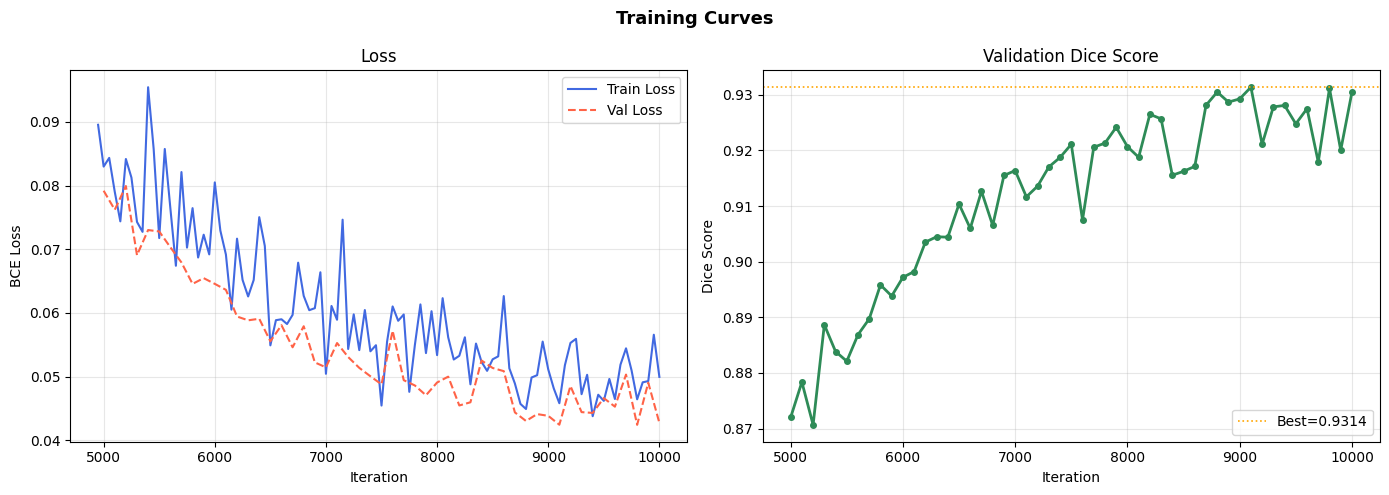

In [15]:
def dice_coefficient(pred_bin, target_bin, eps=1e-6):
    """Compute Dice for two binary numpy/tensor arrays."""
    pred_bin   = pred_bin.bool().float()
    target_bin = target_bin.bool().float()
    intersection = (pred_bin * target_bin).sum()
    return (2.0 * intersection + eps) / (pred_bin.sum() + target_bin.sum() + eps)


def validate(model, val_loader, criterion, device):
    """Run one validation epoch; return mean loss and mean Dice."""
    model.eval()
    losses, dices = [], []
    with torch.no_grad():
        for batch in val_loader:
            inp  = batch["input"].to(device)
            gt   = batch["binary_mask"].to(device)
            pred = model(inp)
            losses.append(criterion(pred, gt).item())
            pred_bin = (pred > CFG["sigmoid_threshold"]).float()
            dices.append(dice_coefficient(pred_bin, gt).item())
    model.train()
    return float(np.mean(losses)), float(np.mean(dices))


# ── DataLoaders ──────────────────────────────────────────────────────────────
# If the CSV only has test subjects (as in the demo), we fall back gracefully.
def make_loader(ds, shuffle):
    if len(ds) == 0:
        return None
    return DataLoader(ds, batch_size=CFG["batch_size"], shuffle=shuffle,
                      num_workers=2, pin_memory=(device.type == "cuda"), drop_last=True)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)

if train_loader is None:
    print("⚠ No training samples — using test set as a stand-in for the demo.")
    _train_dl_fallback = make_loader(test_ds, shuffle=True)
else:
    _train_dl_fallback = train_loader

if val_loader is None:
    print("⚠ No validation samples — using test set as a stand-in for the demo.")
    _val_dl_fallback = make_loader(test_ds, shuffle=False)
else:
    _val_dl_fallback = val_loader

# ── Optimiser & logging structures ───────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(),
                             lr=CFG["lr"],
                             weight_decay=CFG["weight_decay"])

train_log_iters, train_log_loss = [], []
val_log_iters, val_log_loss, val_log_dice = [], [], []
best_val_dice = -1.0
start_iteration = 1

# ── RESUME LOGIC ─────────────────────────────────────────────────────────────
if os.path.exists(CFG["resume_path"]):
    print(f"Loading checkpoint from '{CFG['resume_path']}' to resume training...")
    ckpt = torch.load(CFG["resume_path"], map_location=device)
    
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])  # Keeps Adam momentums intact
    best_val_dice = ckpt.get("val_dice", -1.0)
    start_iteration = ckpt.get("iteration", 0) + 1      # Start from the next iteration
    
    print(f"Successfully resumed! Starting from Iteration {start_iteration} (Best Previous Dice: {best_val_dice:.4f})")
else:
    print("No checkpoint found. Starting training from scratch.")

# ── Infinite data iterator helper ────────────────────────────────────────────
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

# ── Training loop ─────────────────────────────────────────────────────────────
print(f"Starting training for {CFG['iterations']:,} iterations …")
print("─" * 60)

model.train()
running_loss = 0.0
data_iter    = infinite_loader(_train_dl_fallback)

# CHANGE: Start loop from `start_iteration` instead of 1
for iteration in range(start_iteration, CFG["iterations"] + 1):
    batch = next(data_iter)
    inp   = batch["input"].to(device)         
    gt    = batch["binary_mask"].to(device)   

    optimizer.zero_grad()
    pred = model(inp)
    loss = criterion(pred, gt)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # ── Log training loss ─────────────────────────────────────────────────
    if iteration % CFG["log_every"] == 0:
        avg_loss = running_loss / CFG["log_every"]
        train_log_iters.append(iteration)
        train_log_loss.append(avg_loss)
        running_loss = 0.0
        print(f"  Iter {iteration:6d}/{CFG['iterations']}  |  Train Loss: {avg_loss:.5f}")

    # ── Validation pass ───────────────────────────────────────────────────
    if iteration % CFG["val_every"] == 0:
        val_loss, val_dice = validate(model, _val_dl_fallback, criterion, device)
        val_log_iters.append(iteration)
        val_log_loss.append(val_loss)
        val_log_dice.append(val_dice)
        print(f"  ↳ Val  Loss: {val_loss:.5f}  |  Val  Dice: {val_dice:.4f}")

        # Check against the resumed best_val_dice
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({
                "iteration": iteration,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_dice": val_dice,
            }, CFG["checkpoint_path"])
            print(f"    ★ New best Dice={val_dice:.4f} — checkpoint saved.")
            
        # SAFETY NET: Always save the latest state so progress isn't lost on timeout
        torch.save({
            "iteration": iteration,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_dice": val_dice,
        }, "latest_model.pth")
            
print(f"\nTraining complete. Best Val Dice: {best_val_dice:.4f}")
print(f"Checkpoint saved to: {CFG['checkpoint_path']}")

# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves", fontsize=13, fontweight="bold")

axes[0].plot(train_log_iters, train_log_loss, color="royalblue", lw=1.5, label="Train Loss")
if val_log_iters:
    axes[0].plot(val_log_iters, val_log_loss, color="tomato", lw=1.5, linestyle="--", label="Val Loss")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

if val_log_iters:
    axes[1].plot(val_log_iters, val_log_dice, color="seagreen", lw=2, marker="o", ms=4)
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Dice Score")
    axes[1].set_title("Validation Dice Score"); axes[1].grid(alpha=0.3)
    axes[1].axhline(best_val_dice, color="orange", lw=1.2, linestyle=":", label=f"Best={best_val_dice:.4f}")
    axes[1].legend()
else:
    axes[1].set_title("Validation Dice (no val data)")

plt.tight_layout()
plt.show()

## 11. Testing / Inference Loop

1. Load best checkpoint
2. For each test subject, pass each vertebra crop + heatmap through the model
3. Threshold sigmoid output at 0.5 → binary prediction
4. Re-project each vertebra patch back to full-volume space (highest-response wins)
5. Save the reconstructed label volume as NIfTI
6. Plot predicted segmentation overlaid with GT contours

In [ ]:
import gc

def merge_crop_into_volume(pred_prob, vol_shape, offset, crop_size, label, pred_label_vol, max_prob_vol, sigmoid_thr=0.5):
    """
    Directly updates the master prediction volumes IN-PLACE to save RAM.
    This entirely prevents the Kaggle Out-of-Memory (OOM) error.
    """
    ox, oy, oz = offset
    sx, sy, sz = crop_size
    vx, vy, vz = vol_shape

    # Clamp to valid volume bounds
    xs = max(ox, 0); ys = max(oy, 0); zs = max(oz, 0)
    xe = min(ox + sx, vx); ye = min(oy + sy, vy); ze = min(oz + sz, vz)

    # Indices within the small crop itself
    px0 = xs - ox; py0 = ys - oy; pz0 = zs - oz
    px1 = px0 + (xe - xs); py1 = py0 + (ye - ys); pz1 = pz0 + (ze - zs)

    # Extract the valid portions
    crop_valid = pred_prob[px0:px1, py0:py1, pz0:pz1]
    current_max = max_prob_vol[xs:xe, ys:ye, zs:ze]

    # Find where this crop has higher probability than what's already there AND > threshold
    update_mask = (crop_valid > sigmoid_thr) & (crop_valid > current_max)

    # Update in-place
    max_prob_vol[xs:xe, ys:ye, zs:ze][update_mask] = crop_valid[update_mask]
    pred_label_vol[xs:xe, ys:ye, zs:ze][update_mask] = label

# ── Load best checkpoint ──────────────────────────────────────────────────────
if os.path.exists(CFG["checkpoint_path"]):
    ckpt = torch.load(CFG["checkpoint_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Loaded checkpoint from iteration {ckpt['iteration']}  "
          f"(val Dice={ckpt['val_dice']:.4f})")
else:
    print("No checkpoint found — using current model weights.")

model.eval()

# ── Test loop ─────────────────────────────────────────────────────────────────
test_results = []   # list of dicts per (subject, label)
df_test = pd.read_csv(CFG["csv_path"])
df_test = df_test[df_test["type"] == "test"].reset_index(drop=True)

for _, row in df_test.iterrows():
    subj_name = row["name"]
    print(f"\nRunning inference on: {subj_name}")
    try:
        vol_nib_  = nib.load(str(row["image_path"]))
        
        mask_path = row.get("mask_path")
        if pd.isna(mask_path) or not str(mask_path).strip():
            mask_nib_ = None
        else:
            mask_nib_ = nib.load(str(mask_path))
            
        # FIX 1: Extract affine references required to map real space -> voxel space safely
        vol_pp, mask_pp, ras_affine, zooms, orig_affine = full_preprocess(vol_nib_, mask_nib_)
        vol_shape = vol_pp.shape
        
        # OOM SAFETY GUARD: Skip if volume is gigantically huge
        total_voxels = np.prod(vol_shape)
        if total_voxels > 100_000_000:
            print(f"  ⚠ Skipping {subj_name}: Volume too large for Kaggle RAM limits ({total_voxels:,} voxels).")
            del vol_pp, mask_pp, vol_nib_
            gc.collect()
            continue
        
        # FIX 2: Safely convert JSON centroids into 1mm mapped space BEFORE cropping
        _, raw_centroids = parse_centroid_json(str(row["centroid_json_path"]))
        centroids_1mm = centroids_to_voxel_1mm(raw_centroids, orig_affine, ras_affine, zooms)

        # Initialize Master maps — Memory efficient 
        pred_label_vol = np.zeros(vol_shape, dtype=np.int16)
        max_prob_vol   = np.zeros(vol_shape, dtype=np.float32)

        for label, vox_idx in centroids_1mm.items():
            # Use correctly mapped voxel indices
            ct_crop, offset = crop_volume_around_centroid(vol_pp, vox_idx, CFG["crop_size"])
            heatmap         = generate_gaussian_heatmap(CFG["crop_size"], CFG["heatmap_sigma"])

            inp_t = torch.from_numpy(
                np.stack([ct_crop, heatmap], axis=0)[None]
            ).to(device)

            with torch.no_grad():
                pred_sigmoid = model(inp_t)[0, 0].cpu().numpy()

            # Merge directly into master array entirely avoiding RAM explosion
            merge_crop_into_volume(pred_sigmoid, vol_shape, offset, CFG["crop_size"], 
                                   label, pred_label_vol, max_prob_vol, CFG["sigmoid_threshold"])

        unique_pred = np.unique(pred_label_vol)
        print(f"  Predicted labels: {unique_pred}")

        # ── Save as NIfTI ─────────────────────────────────────────────────
        save_path = f"pred_{subj_name}_seg.nii.gz"
        out_nib   = nib.Nifti1Image(pred_label_vol, np.eye(4))
        nib.save(out_nib, save_path)
        print(f"  Saved prediction → {save_path}")

        # ── Store for evaluation ──────────────────────────────────────────
        for label in sorted(centroids_1mm.keys()):
            # MASSIVE RAM FIX: Evaluate as strict boolean directly (Saves 75% memory load vs Float32)
            pred_bin = (pred_label_vol == label)
            gt_bin   = (mask_pp == label)
            
            test_results.append({
                "subject": subj_name,
                "label":   label,
                "pred_bin": pred_bin,
                "gt_bin":   gt_bin,
            })

        # ── Visualise: prediction overlay on GT ───────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Test Prediction — {subj_name}", fontsize=12, fontweight="bold")
        
        cx, cy, cz = vol_shape[0]//2, vol_shape[1]//2, vol_shape[2]//2
        
        # FIX 3: Labels matched correctly with the sliced axes mathematically
        slices = [
            (vol_pp[cx, :, :],  pred_label_vol[cx, :, :],  mask_pp[cx, :, :],  "Sagittal (mid R-L)"),
            (vol_pp[:, cy, :], pred_label_vol[:, cy, :], mask_pp[:, cy, :], "Coronal (mid A-P)"),
            (vol_pp[:, :, cz], pred_label_vol[:, :, cz], mask_pp[:, :, cz], "Axial (mid I-S)"),
        ]
        
        for ax, (vol_sl, pred_sl, gt_sl, lbl) in zip(axes, slices):
            ax.imshow(vol_sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
            
            if pred_sl.max() > 0:
                ax.imshow(np.ma.masked_where(pred_sl == 0, pred_sl).T,
                          cmap="autumn", origin="lower", alpha=0.5, vmin=1)
                
            gt_levels = np.unique(gt_sl)[1:]
            if len(gt_levels) > 0:
                ax.contour(gt_sl.T, levels=gt_levels, colors="cyan",
                           linewidths=0.8, linestyles="--")
                           
            ax.set_title(f"{lbl}", fontsize=10)
            ax.axis("off")
            
        from matplotlib.lines import Line2D
        legend_elems = [
            mpatches.Patch(facecolor="orange", alpha=0.6, label="Prediction"),
            Line2D([0], [0], color="cyan", lw=1.5, linestyle="--", label="GT contour"),
        ]
        axes[2].legend(handles=legend_elems, loc="lower right", fontsize=8)
        plt.tight_layout(); plt.show()

        # AGGRESSIVE MEMORY CLEANUP
        del vol_pp, mask_pp, pred_label_vol, max_prob_vol, vol_nib_
        if mask_nib_ is not None:
             del mask_nib_
        gc.collect()

    except (FileNotFoundError, Exception) as e:
        print(f"  ✗ Error: {e}")

print(f"\nInference complete. Total vertebra results: {len(test_results)}")


Loaded checkpoint from iteration 9100  (val Dice=0.9314)

Running inference on: verse012
  Predicted labels: [ 0 17 18 19 20 21 22]
  Saved prediction → pred_verse012_seg.nii.gz


ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1500x500 with 3 Axes>


Running inference on: verse020
  ✗ Error: could not broadcast input array from shape (0,128,86) into shape (127,128,86)

Running inference on: verse029
  Predicted labels: [ 0  8  9 16 17 18 19 20 21 22 23 24]
  Saved prediction → pred_verse029_seg.nii.gz


ValueError: minvalue must be less than or equal to maxvalue

...

<Figure size 1500x500 with 3 Axes>


Running inference on: verse054
  Predicted labels: [ 0 20 21 22 23 24]
  Saved prediction → pred_verse054_seg.nii.gz


ValueError: minvalue must be less than or equal to maxvalue

<Figure size 1500x500 with 3 Axes>


Running inference on: verse055
  Predicted labels: [ 0 14 15 16 17 18 19 20 21 22 23 24]
  Saved prediction → pred_verse055_seg.nii.gz


## 12. Evaluation Metrics — Dice Score & Hausdorff Distance

$$\text{Dice}(P, G) = \frac{2\,|P \cap G|}{|P| + |G|}$$

$$H(P, G) = \max\!\left(\sup_{p \in P}\inf_{g \in G}d(p,g),\;\sup_{g \in G}\inf_{p \in P}d(p,g)\right)$$

Hausdorff is computed via distance-transform on the binary surface voxels.

In [ ]:
from scipy.ndimage import distance_transform_edt, binary_erosion


def compute_dice(pred_bin, gt_bin, eps=1e-6):
    """Dice coefficient for two binary numpy arrays."""
    intersection = (pred_bin * gt_bin).sum()
    return float((2.0 * intersection + eps) / (pred_bin.sum() + gt_bin.sum() + eps))


def compute_surface(binary_vol):
    """Extract surface voxels (erosion-based boundary)."""
    eroded = binary_erosion(binary_vol)
    return binary_vol.astype(bool) & ~eroded


def compute_hausdorff(pred_bin, gt_bin):
    """
    Hausdorff distance (95th percentile variant for robustness).
    Uses distance transforms on the surface voxels.
    """
    if pred_bin.sum() == 0 or gt_bin.sum() == 0:
        return float("nan")

    surf_pred = compute_surface(pred_bin.astype(bool))
    surf_gt   = compute_surface(gt_bin.astype(bool))

    dt_pred = distance_transform_edt(~surf_pred)  # distance from every voxel to pred surface
    dt_gt   = distance_transform_edt(~surf_gt)    # distance from every voxel to GT surface

    d_pred_to_gt = dt_gt[surf_pred]   # distances from pred surface to nearest GT surface
    d_gt_to_pred = dt_pred[surf_gt]   # distances from GT surface to nearest pred surface

    all_distances = np.concatenate([d_pred_to_gt, d_gt_to_pred])
    return float(np.percentile(all_distances, 95))  # 95th-percentile Hausdorff


# ── Compute metrics per vertebra ─────────────────────────────────────────────
if test_results:
    rows = []
    for r in test_results:
        # SKIP evaluation if there is no ground truth mask for this label
        if r["gt_bin"].sum() == 0:
            print(f"  Subject {r['subject']}  |  Vertebra {r['label']:3d}  "
                  f"|  Skipped (No Ground Truth available)")
            continue
            
        dice = compute_dice(r["pred_bin"], r["gt_bin"])
        hd   = compute_hausdorff(r["pred_bin"], r["gt_bin"])
        rows.append({"subject": r["subject"], "label": r["label"],
                     "Dice": round(dice, 4), "Hausdorff95 (mm)": round(hd, 2)})
        print(f"  Subject {r['subject']}  |  Vertebra {r['label']:3d}  "
              f"|  Dice={dice:.4f}  |  HD95={hd:.2f} mm")

    if rows:
        df_results = pd.DataFrame(rows)
        print("\n── Per-vertebra results ────────────────────────────────────────────")
        print(df_results.to_string(index=False))
        print(f"\nMean Dice  : {df_results['Dice'].mean():.4f}  ± {df_results['Dice'].std():.4f}")
        valid_hd = df_results['Hausdorff95 (mm)'].dropna()
        print(f"Mean HD95  : {valid_hd.mean():.2f}   ± {valid_hd.std():.2f} mm")

        # ── Bar chart ────────────────────────────────────────────────────────────
        labels_sorted = sorted(df_results["label"].unique())
        dice_vals  = [df_results[df_results["label"] == l]["Dice"].mean() for l in labels_sorted]
        hd_vals    = [df_results[df_results["label"] == l]["Hausdorff95 (mm)"].mean() for l in labels_sorted]

        x = np.arange(len(labels_sorted))
        width = 0.35

        fig, ax1 = plt.subplots(figsize=(max(10, len(labels_sorted) * 1.2), 5))
        fig.suptitle("Per-Vertebra Evaluation Metrics", fontsize=13, fontweight="bold")

    bars1 = ax1.bar(x - width/2, dice_vals,  width, color="steelblue", label="Dice Score")
    ax1.set_ylabel("Dice Score", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_ylim(0, 1.1)
    ax1.set_xticks(x); ax1.set_xticklabels([f"L{l}" for l in labels_sorted])
    ax1.set_xlabel("Vertebra Label")

    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, hd_vals, width, color="tomato", alpha=0.8, label="HD95 (mm)")
    ax2.set_ylabel("Hausdorff 95th pct (mm)", color="tomato")
    ax2.tick_params(axis="y", labelcolor="tomato")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

else:
    print("No test results to evaluate. Run inference first.")
